<a href="https://colab.research.google.com/github/SpencerLimSzeSing/mds-fyp/blob/main/notebooks/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library


In [ ]:
import pandas as pd
df = pd.read_csv('/content/weatherAUS.csv')

In [ ]:
import numpy as np # linear algebra
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
import plotly.express as px
import pandas as pd
import folium
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

# location


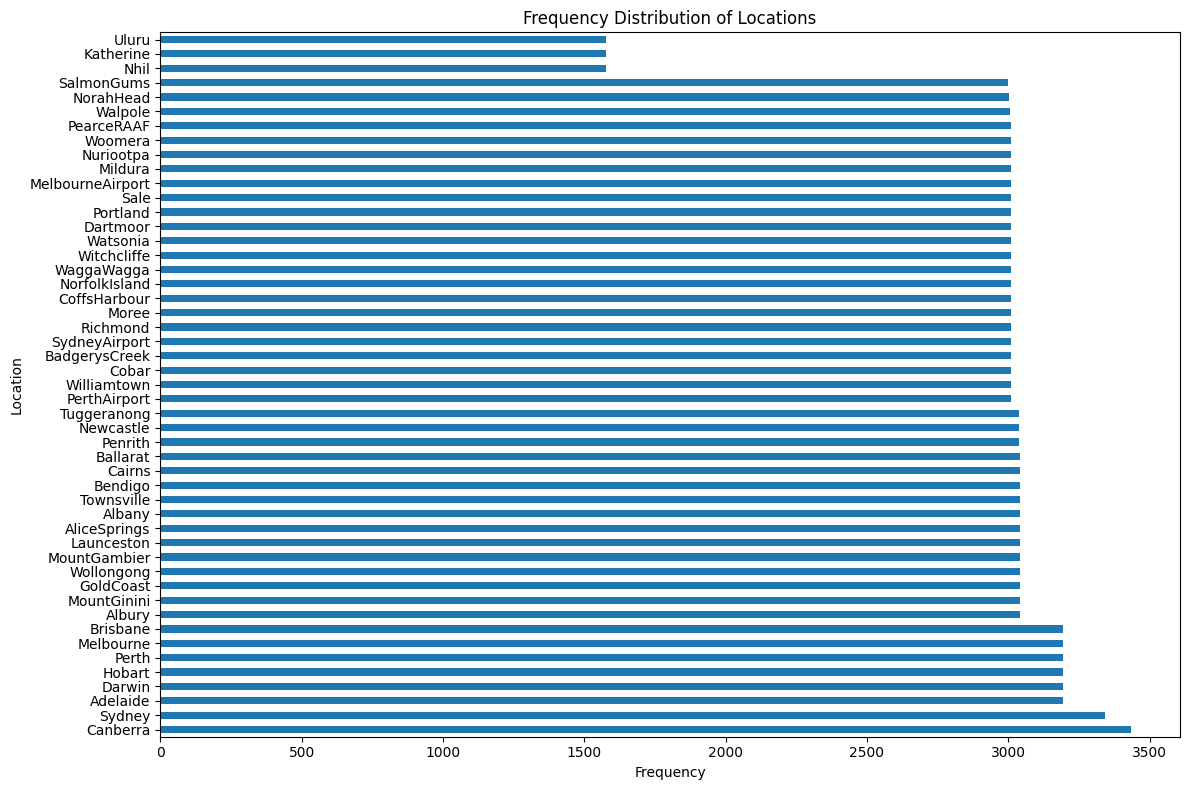

In [ ]:
# Frequency distribution of 'Location'
location_counts = df['Location'].value_counts()

# Plotting the distribution
fig, ax = plt.subplots(figsize=(12, 8))

# Horizontal bar chart
location_counts.plot(kind='barh', ax=ax)

# Customizing the plot
ax.set_title('Frequency Distribution of Locations')
ax.set_xlabel('Frequency')
ax.set_ylabel('Location')
plt.tight_layout()

plt.show()


In [ ]:
# Frequency data for locations
location_frequencies = {
    'Canberra': 3436, 'Sydney': 3344, 'Darwin': 3193, 'Melbourne': 3193, 'Brisbane': 3193,
    'Adelaide': 3193, 'Perth': 3193, 'Hobart': 3193, 'Albany': 3040, 'MountGambier': 3040,
    'Ballarat': 3040, 'Townsville': 3040, 'GoldCoast': 3040, 'Cairns': 3040, 'Launceston': 3040,
    'AliceSprings': 3040, 'Bendigo': 3040, 'Albury': 3040, 'MountGinini': 3040, 'Wollongong': 3040,
    'Newcastle': 3039, 'Tuggeranong': 3039, 'Penrith': 3039, 'Woomera': 3009, 'Nuriootpa': 3009,
    'Cobar': 3009, 'CoffsHarbour': 3009, 'Moree': 3009, 'Sale': 3009, 'PerthAirport': 3009,
    'PearceRAAF': 3009, 'Witchcliffe': 3009, 'BadgerysCreek': 3009, 'Mildura': 3009,
    'NorfolkIsland': 3009, 'MelbourneAirport': 3009, 'Richmond': 3009, 'SydneyAirport': 3009,
    'WaggaWagga': 3009, 'Williamtown': 3009, 'Dartmoor': 3009, 'Watsonia': 3009,
    'Portland': 3009, 'Walpole': 3006, 'NorahHead': 3004, 'SalmonGums': 3001, 'Katherine': 1578,
    'Nhil': 1578, 'Uluru': 1578
}

# Coordinates for locations
location_coords = {
    'Albury': (-36.0737, 146.9135), 'BadgerysCreek': (-33.9209, 150.7253), 'Cobar': (-31.4980, 145.8383),
    'CoffsHarbour': (-30.2963, 153.1141), 'Moree': (-29.4632, 149.8419), 'Newcastle': (-32.9267, 151.7789),
    'NorahHead': (-33.2820, 151.5703), 'NorfolkIsland': (-29.0333, 167.9500), 'Penrith': (-33.7516, 150.6958),
    'Richmond': (-33.6000, 150.7500), 'Sydney': (-33.8688, 151.2093), 'SydneyAirport': (-33.9399, 151.1753),
    'WaggaWagga': (-35.1175, 147.3671), 'Williamtown': (-32.7924, 151.8345), 'Wollongong': (-34.4278, 150.8931),
    'Canberra': (-35.2809, 149.1300), 'Tuggeranong': (-35.4245, 149.0664), 'MountGinini': (-35.5292, 148.7750),
    'Ballarat': (-37.5622, 143.8503), 'Bendigo': (-36.7587, 144.2802), 'Sale': (-38.1067, 147.0680),
    'MelbourneAirport': (-37.6690, 144.8410), 'Melbourne': (-37.8136, 144.9631), 'Mildura': (-34.2049, 142.1376),
    'Nhil': (-36.3313, 141.6547), 'Portland': (-38.3420, 141.6040), 'Watsonia': (-37.7169, 145.0842),
    'Dartmoor': (-37.9181, 141.2836), 'Brisbane': (-27.4698, 153.0251), 'Cairns': (-16.9186, 145.7781),
    'GoldCoast': (-28.0167, 153.4000), 'Townsville': (-19.2580, 146.8183), 'Adelaide': (-34.9285, 138.6007),
    'MountGambier': (-37.8297, 140.7822), 'Nuriootpa': (-34.4685, 138.9964), 'Woomera': (-31.1501, 136.8255),
    'Albany': (-35.0270, 117.8847), 'Witchcliffe': (-34.0185, 115.1013), 'PearceRAAF': (-31.6674, 116.0148),
    'PerthAirport': (-31.9403, 115.9677), 'Perth': (-31.9505, 115.8605), 'SalmonGums': (-32.9833, 121.6333),
    'Walpole': (-34.9762, 116.7333), 'Hobart': (-42.8821, 147.3272), 'Launceston': (-41.4332, 147.1441),
    'AliceSprings': (-23.6980, 133.8807), 'Darwin': (-12.4634, 130.8456), 'Katherine': (-14.4611, 132.2648),
    'Uluru': (-25.3444, 131.0369)
}

# Combine frequencies and coordinates into a DataFrame
location_data = []
for location, frequency in location_frequencies.items():
    if location in location_coords:
        lat, lon = location_coords[location]
        location_data.append({'Location': location, 'Frequency': frequency, 'Latitude': lat, 'Longitude': lon})

df_locations = pd.DataFrame(location_data)

# Create a map
map_center = [-25.2744, 133.7751]  # Center on Australia
m = folium.Map(location=map_center, zoom_start=5)

# Add markers with frequencies
for _, row in df_locations.iterrows():
    folium.CircleMarker(
        location=(row['Latitude'], row['Longitude']),
        radius=row['Frequency'] / 500,  # Scale marker size by frequency
        popup=f"{row['Location']}: {row['Frequency']}",
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.7
    ).add_to(m)

# Save and display the map
m.save("location_distribution_map.html")
m


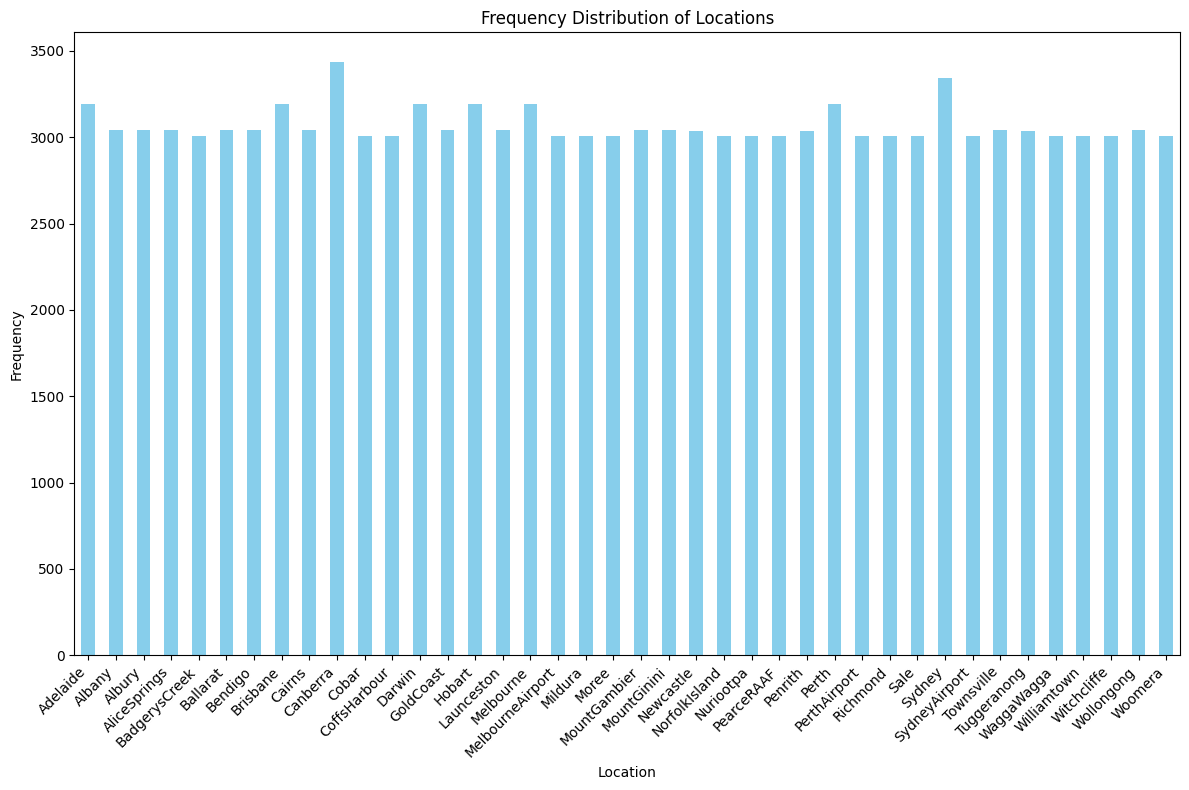

In [ ]:
# Example frequency data
location_counts = pd.Series({
    'Canberra': 3436, 'Sydney': 3344, 'Darwin': 3193, 'Melbourne': 3193, 'Brisbane': 3193,
    'Adelaide': 3193, 'Perth': 3193, 'Hobart': 3193, 'Albany': 3040, 'MountGambier': 3040,
    'Ballarat': 3040, 'Townsville': 3040, 'GoldCoast': 3040, 'Cairns': 3040, 'Launceston': 3040,
    'AliceSprings': 3040, 'Bendigo': 3040, 'Albury': 3040, 'MountGinini': 3040, 'Wollongong': 3040,
    'Newcastle': 3039, 'Tuggeranong': 3039, 'Penrith': 3039, 'Woomera': 3009, 'Nuriootpa': 3009,
    'Cobar': 3009, 'CoffsHarbour': 3009, 'Moree': 3009, 'Sale': 3009, 'PerthAirport': 3009,
    'PearceRAAF': 3009, 'Witchcliffe': 3009, 'BadgerysCreek': 3009, 'Mildura': 3009,
    'NorfolkIsland': 3009, 'MelbourneAirport': 3009, 'Richmond': 3009, 'SydneyAirport': 3009,
    'WaggaWagga': 3009, 'Williamtown': 3009
})

# Sort data alphabetically by location
location_counts_sorted = location_counts.sort_index()

# Plotting
fig, ax = plt.subplots(figsize=(12, 8))
location_counts_sorted.plot(kind='bar', ax=ax, color='skyblue')

# Customizing the plot
ax.set_title('Frequency Distribution of Locations')
ax.set_xlabel('Location')
ax.set_ylabel('Frequency')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()

plt.show()


# number

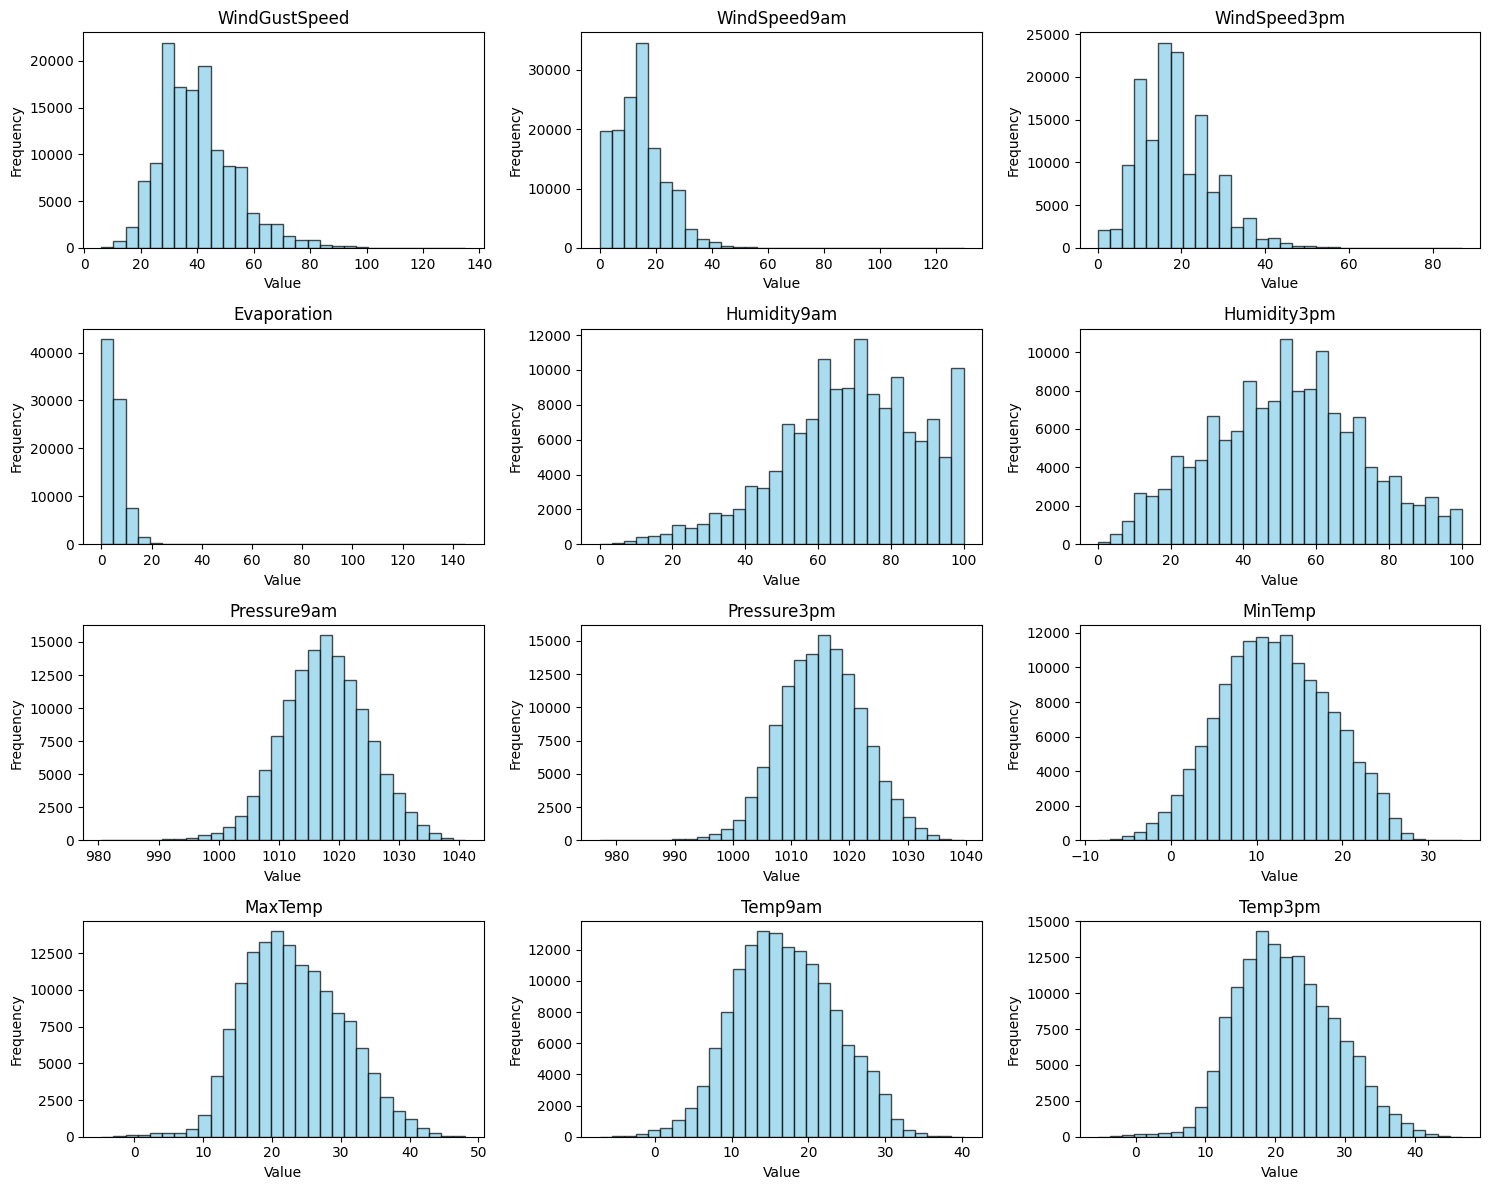

In [ ]:
# List of numerical columns
numerical_columns = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Evaporation',
                     'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm']

# Create histograms
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    axes[i].hist(df[col].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


In [ ]:
# Ensure 'Date' is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Set 'Date' as the index
df.set_index('Date', inplace=True)

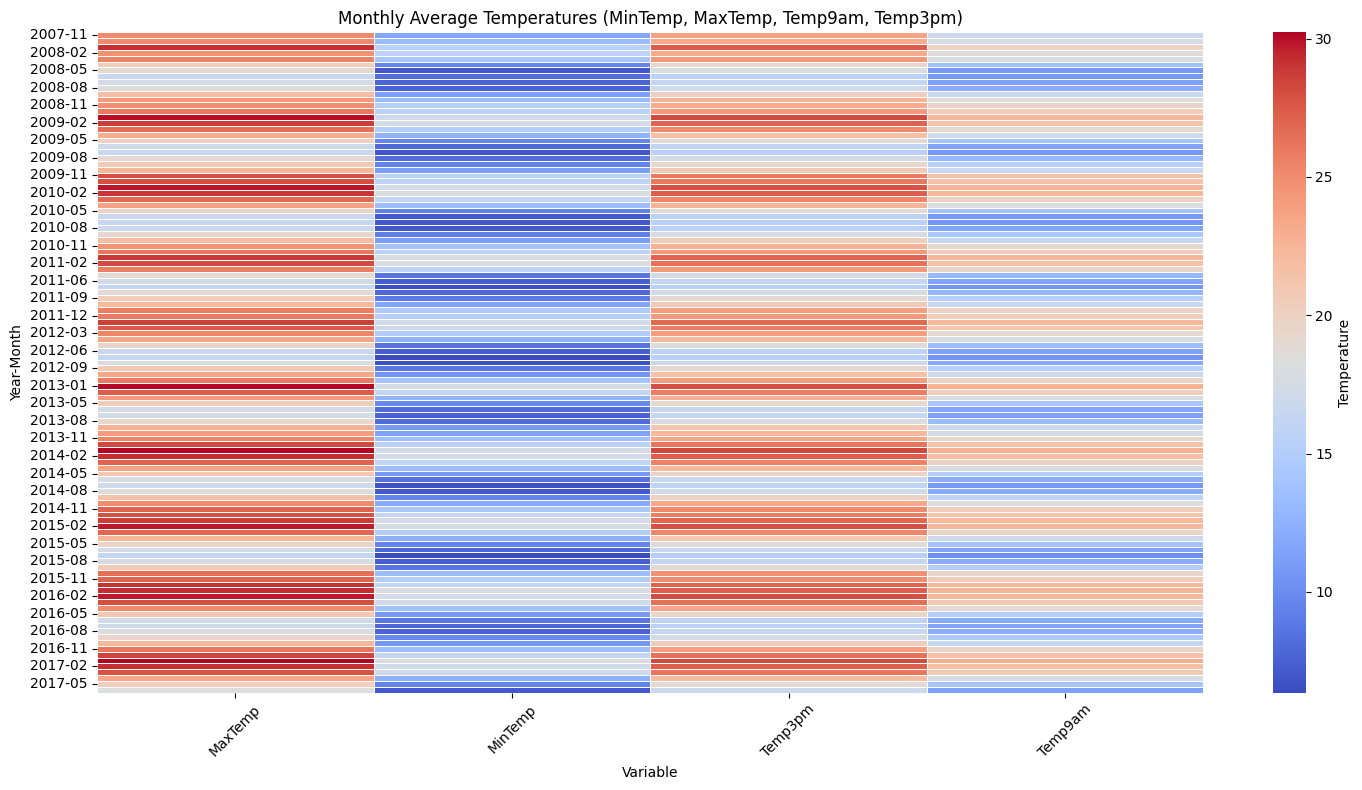

In [ ]:
# Resample data to monthly means, only on numeric columns
heatmap_data = df[['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm']].resample('ME').mean().reset_index()

# Extract Year-Month for the heatmap
heatmap_data['YearMonth'] = heatmap_data['Date'].dt.to_period('M')

# Pivot the data to create a matrix for the heatmap
heatmap_pivot = heatmap_data.melt(id_vars='YearMonth', value_vars=['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm'],
                                  var_name='Variable', value_name='Temperature')

# Create the heatmap
plt.figure(figsize=(15, 8))
heatmap_matrix = heatmap_pivot.pivot_table(index='YearMonth', columns='Variable', values='Temperature')

sns.heatmap(
    heatmap_matrix,
    cmap='coolwarm',
    annot=False,
    cbar_kws={'label': 'Temperature'},
    linewidths=0.5
)

plt.title('Monthly Average Temperatures (MinTemp, MaxTemp, Temp9am, Temp3pm)')
plt.ylabel('Year-Month')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


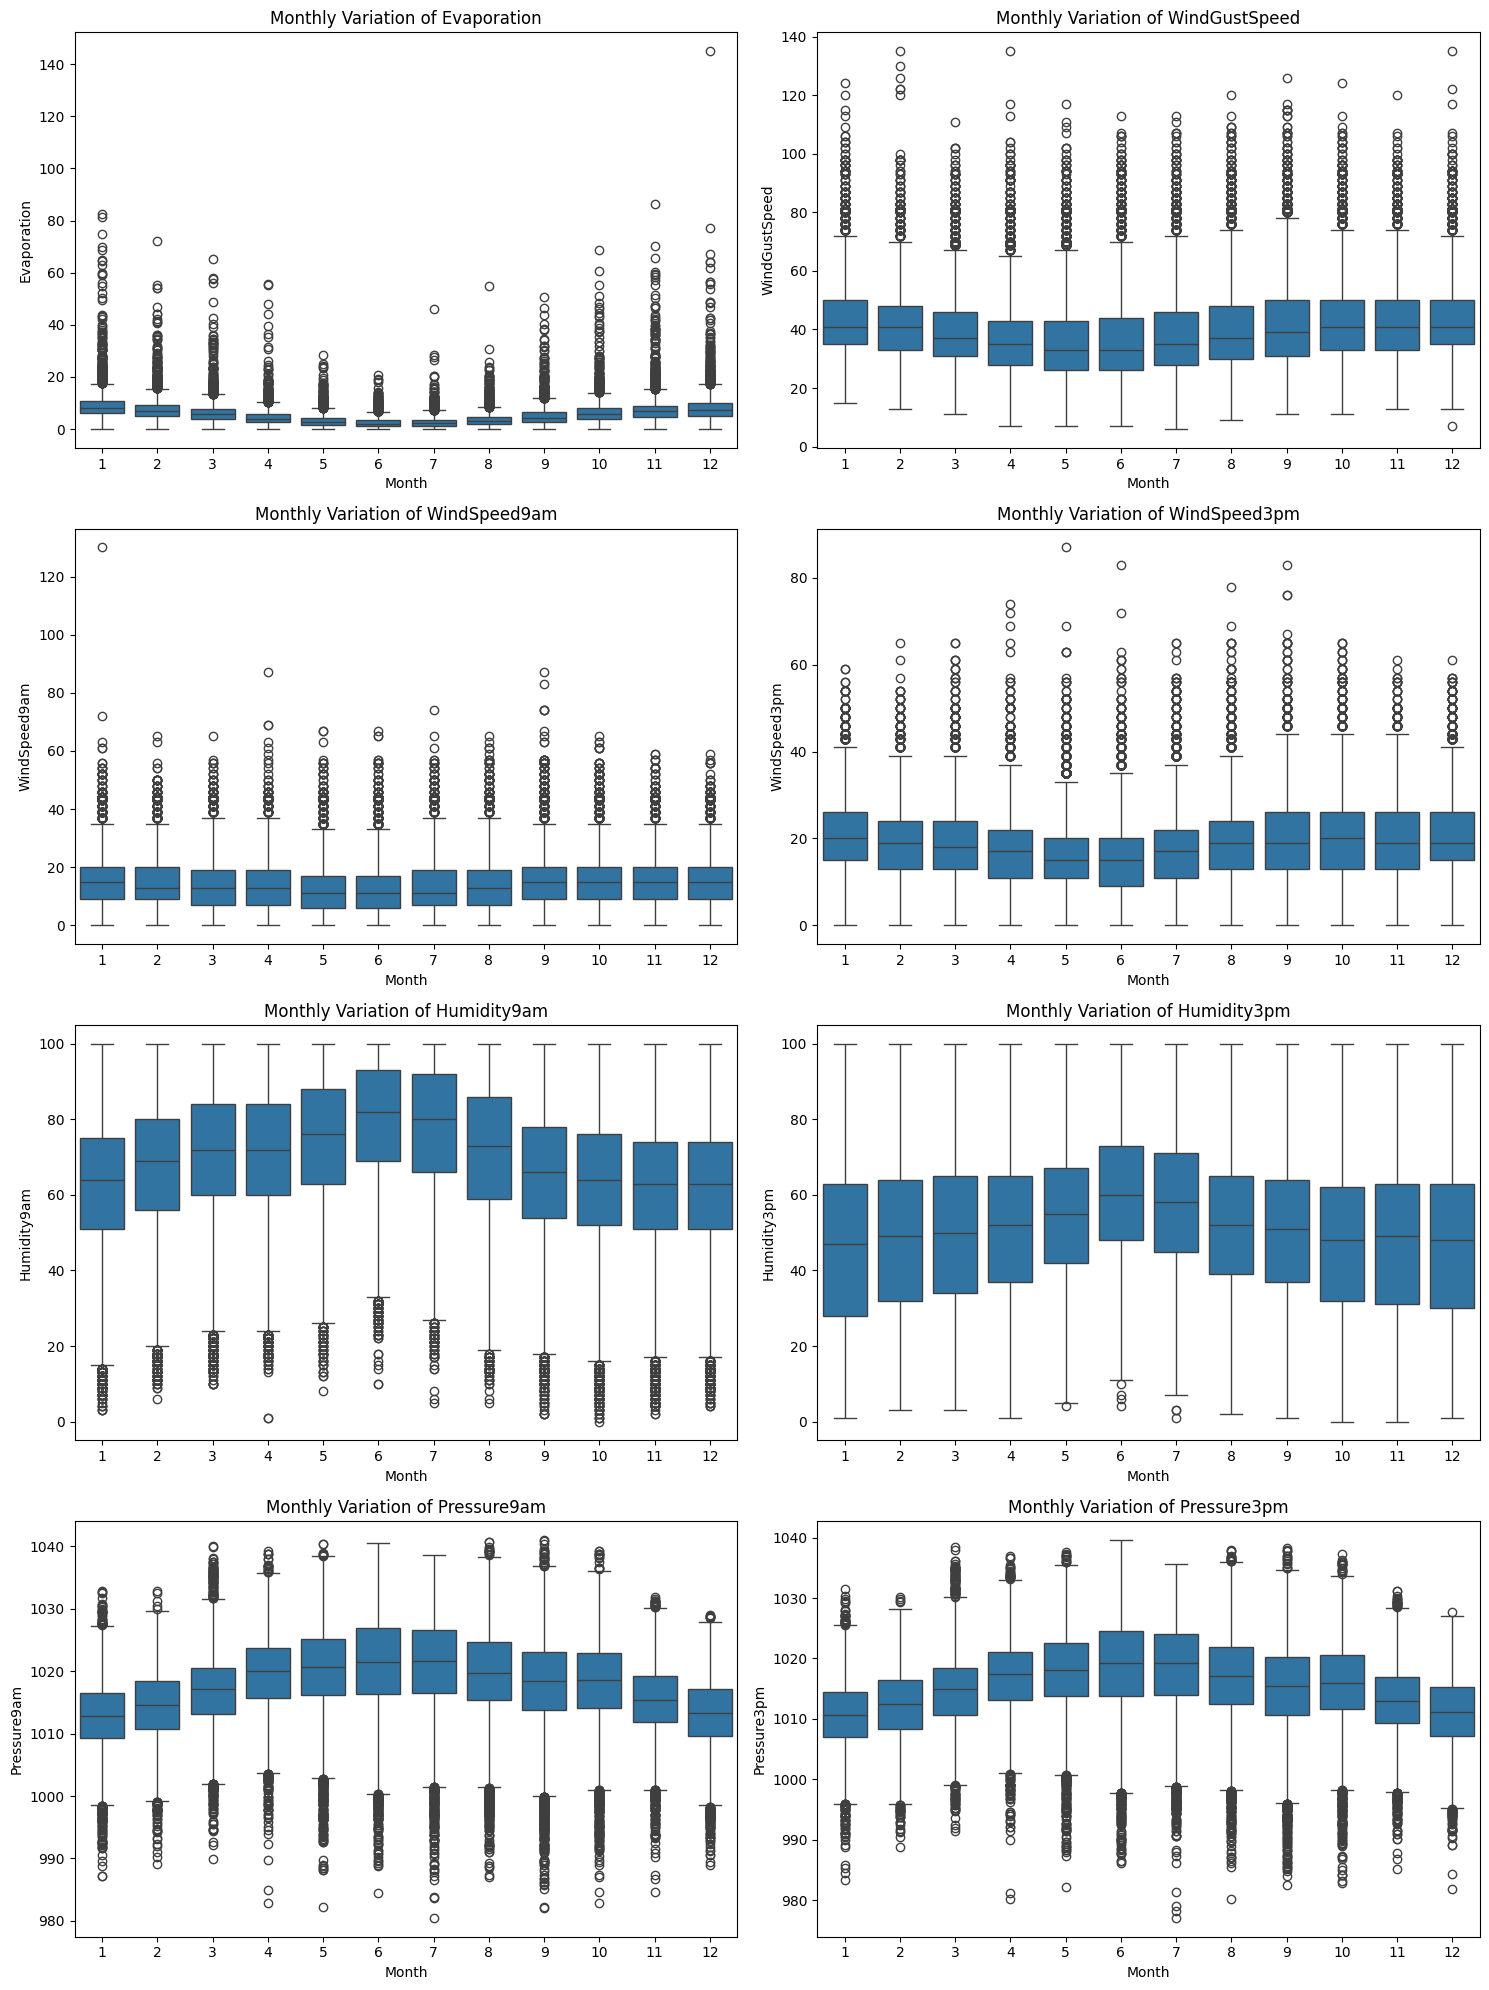

In [ ]:

df = df.reset_index()
df['Month'] = pd.to_datetime(df['Date']).dt.month

# Variables to visualize
variables = ['Evaporation', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
             'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm']

# Create facet grid
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))
axes = axes.flatten()

for i, var in enumerate(variables):
    sns.boxplot(x='Month', y=var, data=df, ax=axes[i])
    axes[i].set_title(f'Monthly Variation of {var}')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()


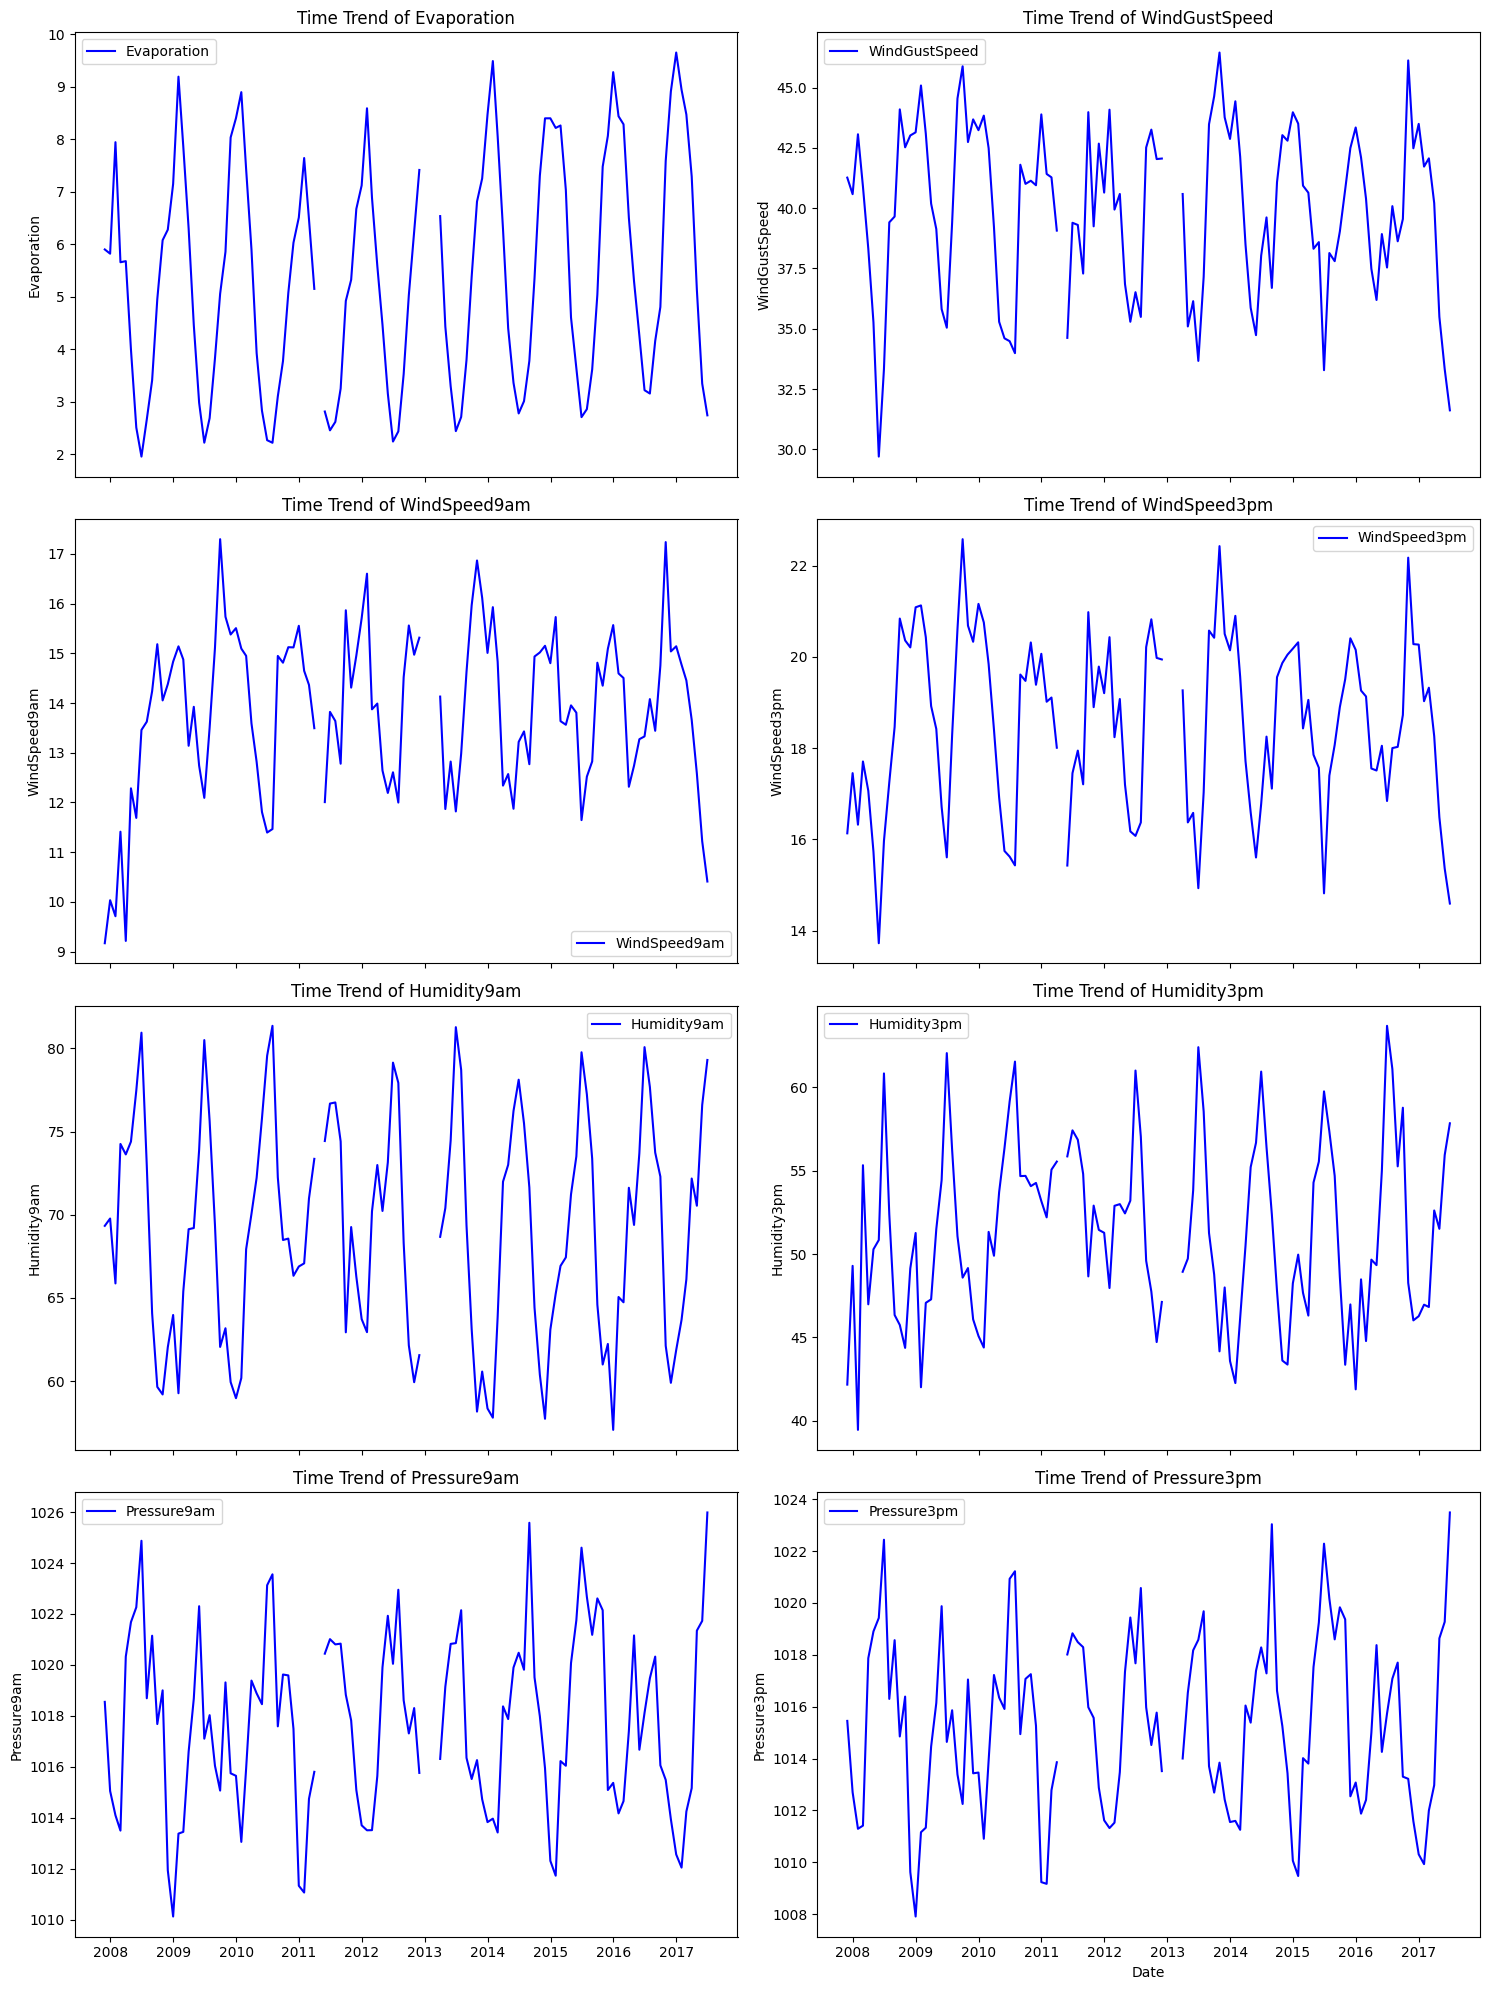

In [ ]:
# 1. Standardize column names (removes spaces and makes everything lowercase)
df.columns = df.columns.str.strip().str.lower()

# 2. Convert the 'date' column to datetime format
# Use errors='coerce' to handle any non-date strings gracefully
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 3. Drop rows where 'date' couldn't be parsed (optional but recommended)
df = df.dropna(subset=['date'])

# 4. Resample: Select numeric columns + the date column, then resample 'on' date
# This is cleaner than setting the index manually
df_resampled = (
    df.select_dtypes(include=['number', 'datetime'])
    .resample('ME', on='date')
    .mean()
)

# 5. Plotting
variables = ['evaporation', 'windgustspeed', 'windspeed9am', 'windspeed3pm',
             'humidity9am', 'humidity3pm', 'pressure9am', 'pressure3pm']

# Filter variables to only those that actually exist in the dataframe
variables = [v for v in variables if v in df_resampled.columns]

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20), sharex=True)
axes = axes.flatten()

for i, col in enumerate(variables):
    axes[i].plot(df_resampled.index, df_resampled[col], label=col, color='blue')
    axes[i].set_title(f'Time Trend of {col}')
    axes[i].set_ylabel(col)
    axes[i].legend()

plt.xlabel('Date')
plt.tight_layout()
plt.show()

Columns in df_resampled: Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='object')


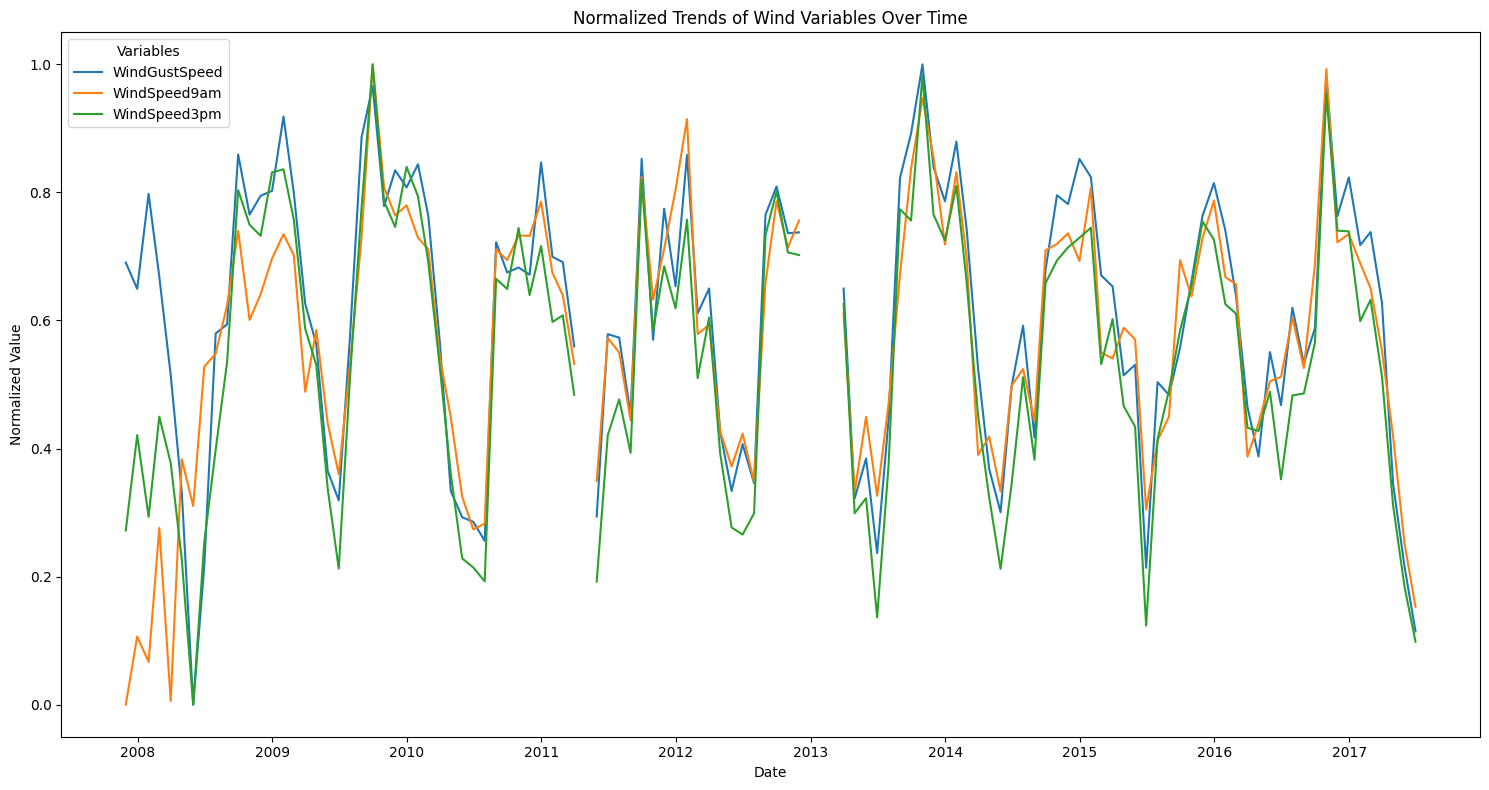

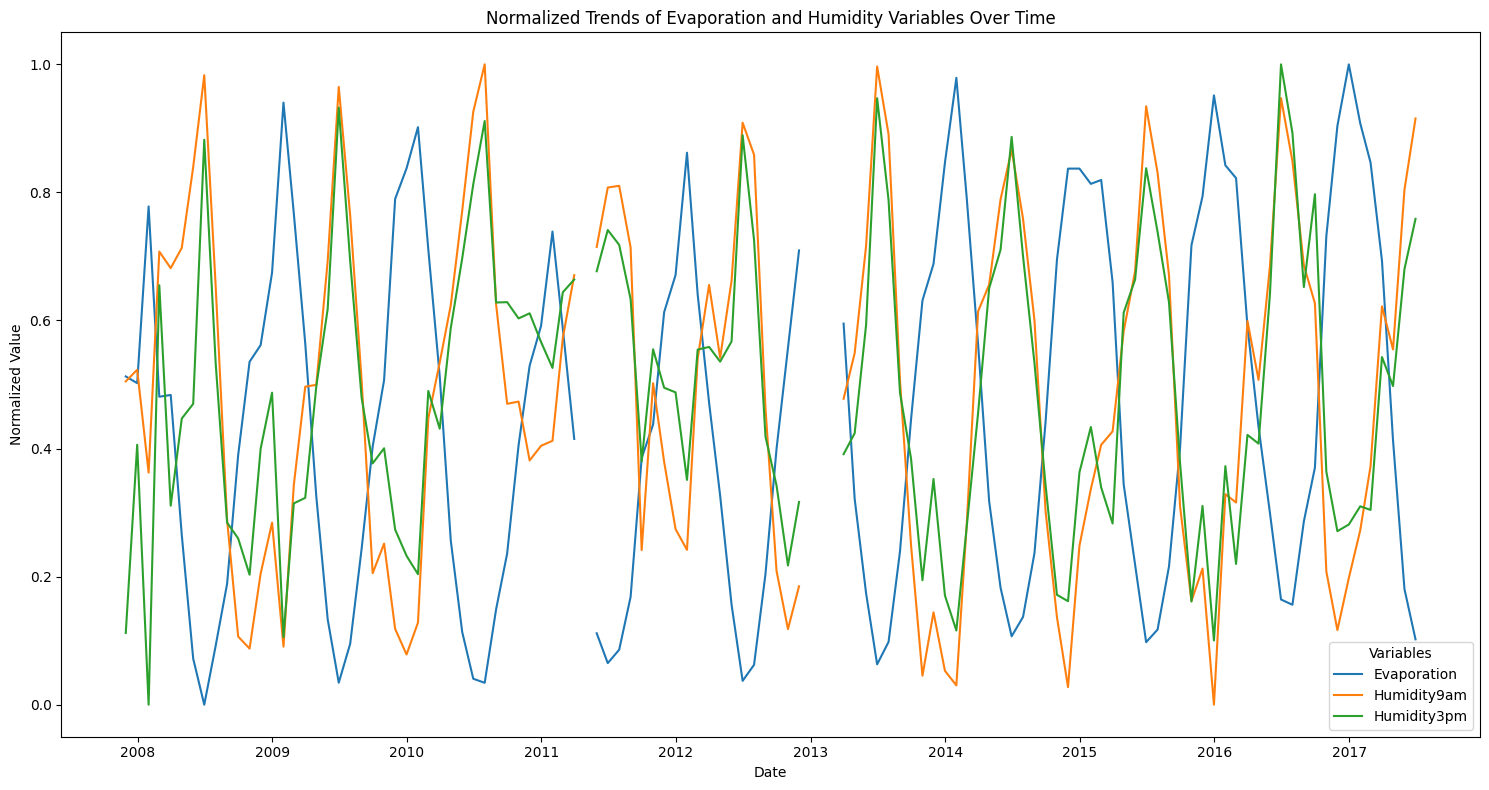

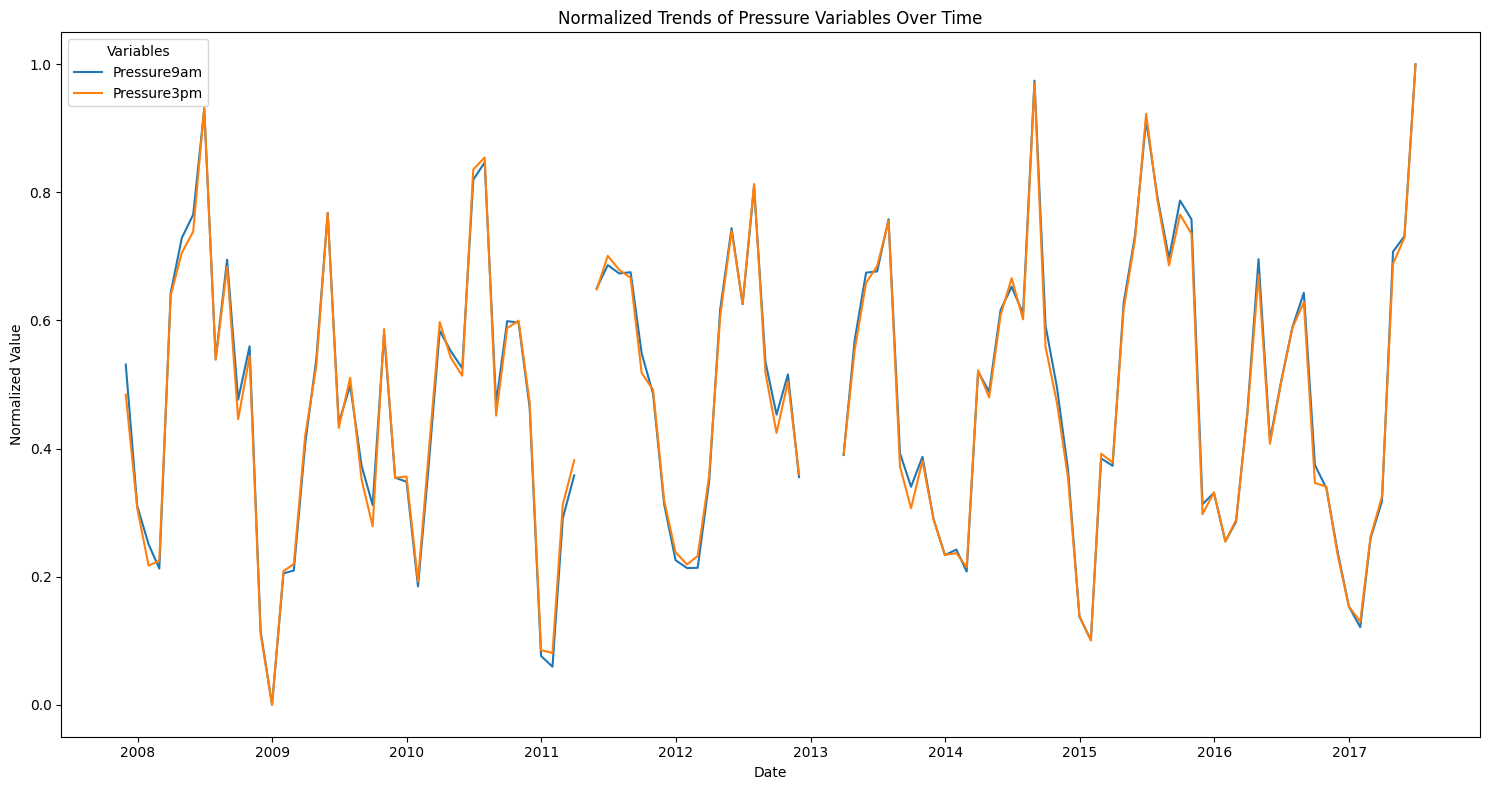

In [ ]:
# Check column names and handle missing values
print("Columns in df_resampled:", df_resampled.columns)

# Normalize data for the specified variables
variables = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
             'Evaporation', 'Humidity9am', 'Humidity3pm',
             'Pressure9am', 'Pressure3pm']

# Filter variables that exist in the dataset
available_variables = [col for col in variables if col in df_resampled.columns]

# Normalize only available variables
df_normalized = (df_resampled[available_variables] - df_resampled[available_variables].min()) / (df_resampled[available_variables].max() - df_resampled[available_variables].min())

# Group variables
group1 = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']
group2 = ['Evaporation', 'Humidity9am', 'Humidity3pm']
group3 = ['Pressure9am', 'Pressure3pm']

# Function to plot each group
def plot_group(variables, title):
    plt.figure(figsize=(15, 8))
    for col in variables:
        if col in df_normalized.columns:  # Ensure the column exists
            plt.plot(df_normalized.index, df_normalized[col], label=col)
    plt.title(f'Normalized Trends of {title} Over Time')
    plt.xlabel('Date')
    plt.ylabel('Normalized Value')
    plt.legend(title='Variables')
    plt.tight_layout()
    plt.show()

# Plot each group
plot_group(group1, 'Wind Variables')
plot_group(group2, 'Evaporation and Humidity Variables')
plot_group(group3, 'Pressure Variables')


# Rainfall

In [ ]:
df1 = pd.read_csv('/content/weatherAUS.csv')

Rainfall Category Distribution:
 Rainfall_Category
No Rain            125638
Moderate Rain       12478
Heavy Rain           3275
Very Heavy Rain       807
Name: count, dtype: int64

Rainfall Category Proportions (%):
 Rainfall_Category
No Rain            88.354267
Moderate Rain       8.775088
Heavy Rain          2.303127
Very Heavy Rain     0.567519
Name: proportion, dtype: float64


<ipython-input-5-031c4e67e0de>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df1['Rainfall_Category'], order=labels, palette='viridis')


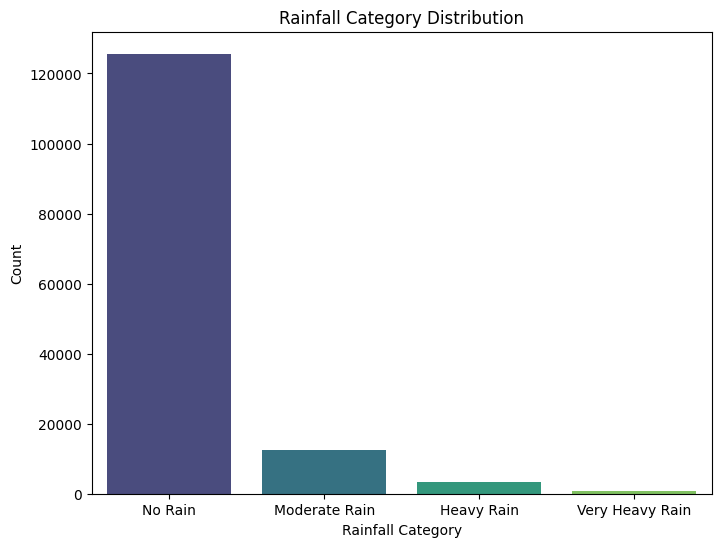

In [ ]:
# Define bins and labels for rainfall categories
bins = [0, 5, 20, 50, df1['Rainfall'].max()]
labels = ['No Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']

# Create binned categories
df1['Rainfall_Category'] = pd.cut(df1['Rainfall'], bins=bins, labels=labels, right=False)

# Check the distribution
rainfall_category_counts = df1['Rainfall_Category'].value_counts()
print("Rainfall Category Distribution:\n", rainfall_category_counts)

# Calculate proportions
rainfall_category_proportions = df1['Rainfall_Category'].value_counts(normalize=True) * 100
print("\nRainfall Category Proportions (%):\n", rainfall_category_proportions)

# Bar plot
plt.figure(figsize=(8, 6))
sns.countplot(x=df1['Rainfall_Category'], order=labels, palette='viridis')
plt.title('Rainfall Category Distribution')
plt.xlabel('Rainfall Category')
plt.ylabel('Count')
plt.show()

In [ ]:
# Ensure the Date column in df1 is in datetime format
df1['Date'] = pd.to_datetime(df1['Date'], errors='coerce')

# Check for invalid dates and handle them
if df1['Date'].isnull().sum() > 0:
    print(f"Invalid dates found: {df1['Date'].isnull().sum()}")
    df1 = df1.dropna(subset=['Date'])  # Drop rows with invalid dates if necessary

# Group by month and calculate the counts for each category
df1['YearMonth'] = df1['Date'].dt.to_period('M')
rainfall_trend = df1.groupby(['YearMonth', 'Rainfall_Category']).size().unstack(fill_value=0)

# Normalize to get proportions (optional)
rainfall_trend_proportion = rainfall_trend.div(rainfall_trend.sum(axis=1), axis=0)

<ipython-input-6-72bfa0013098>:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rainfall_trend = df1.groupby(['YearMonth', 'Rainfall_Category']).size().unstack(fill_value=0)


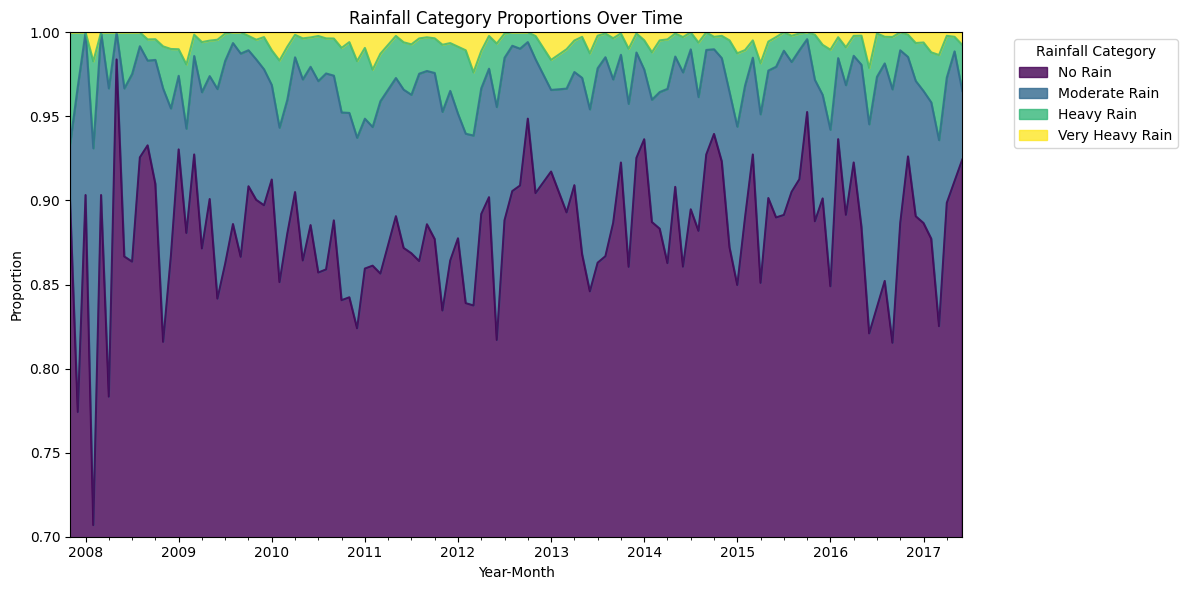

In [ ]:
# Plot time trend: Stacked Area Plot
plt.figure(figsize=(12, 6))
rainfall_trend_proportion.plot.area(ax=plt.gca(), colormap='viridis', alpha=0.8)
plt.ylim(0.70, 1.0)  # Set the desired y-axis range
plt.title('Rainfall Category Proportions Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Proportion')
plt.legend(title='Rainfall Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


<ipython-input-8-302f75f8ddd3>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rainfall_by_location = df1.groupby(['Location', 'Rainfall_Category']).size().unstack(fill_value=0)


<Figure size 1200x600 with 0 Axes>

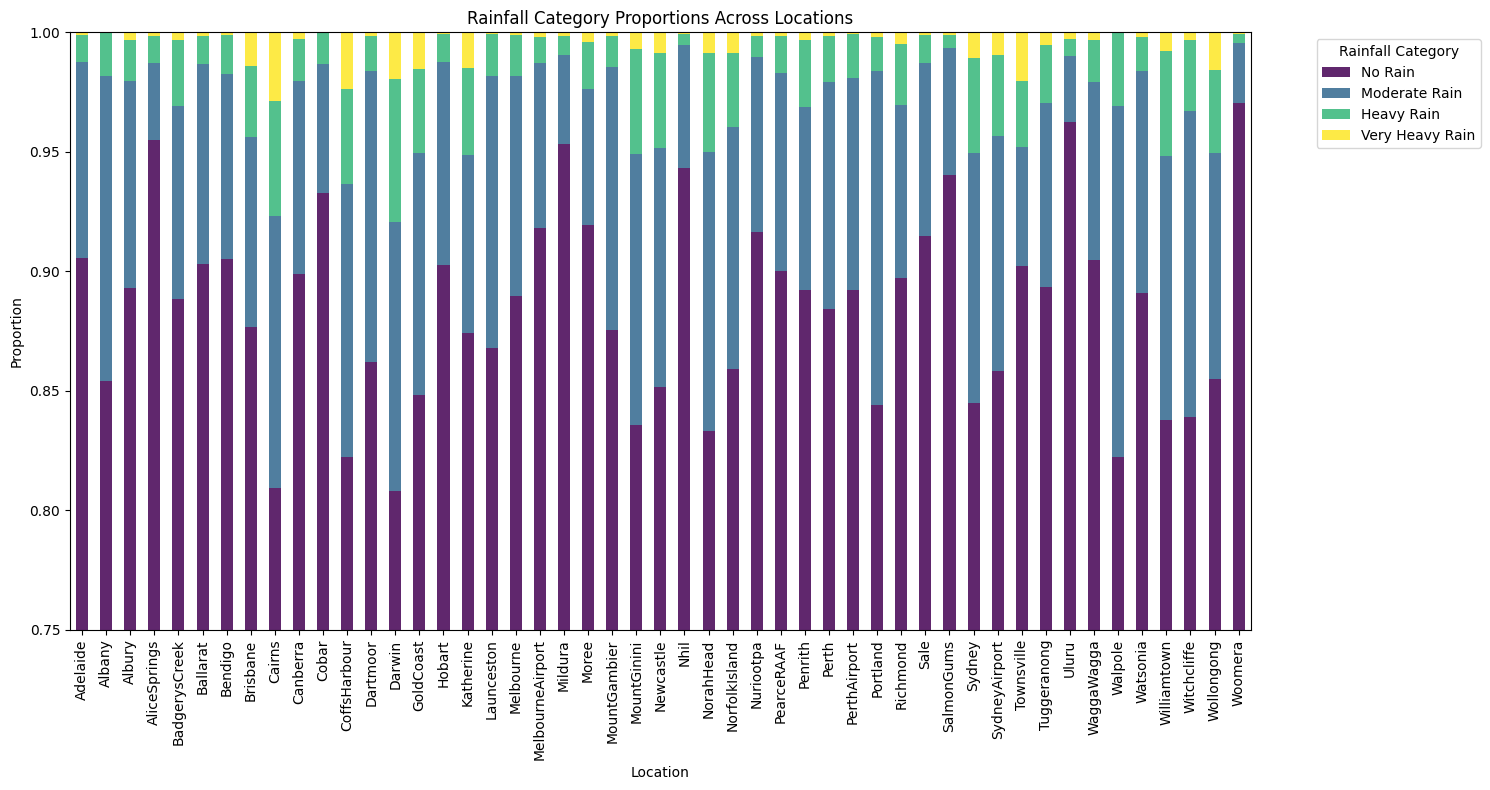

In [ ]:
# Group data by Location and Rainfall_Category
rainfall_by_location = df1.groupby(['Location', 'Rainfall_Category']).size().unstack(fill_value=0)

# Normalize to proportions
rainfall_by_location_proportion = rainfall_by_location.div(rainfall_by_location.sum(axis=1), axis=0)

# Plot stacked bar chart
plt.figure(figsize=(12, 6))
rainfall_by_location_proportion.plot(
    kind='bar', stacked=True, figsize=(15, 8), colormap='viridis', alpha=0.85
)
plt.ylim(0.75, 1.0)  # Set the desired y-axis range
plt.title('Rainfall Category Proportions Across Locations')
plt.xlabel('Location')
plt.ylabel('Proportion')
plt.legend(title='Rainfall Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)  # Rotate x-axis labels vertically

plt.tight_layout()
plt.show()


Grouping by Geographic Regions:
1. New South Wales (NSW):
'Albury', 'BadgerysCreek', 'Cobar', 'CoffsHarbour', 'Moree', 'Newcastle', 'NorahHead', 'Penrith', 'Richmond', 'Sydney', 'SydneyAirport', 'WaggaWagga', 'Williamtown', 'Wollongong'
2. Australian Capital Territory (ACT):
'Canberra', 'Tuggeranong', 'MountGinini'
3. Victoria (VIC):
'Ballarat', 'Bendigo', 'Sale', 'MelbourneAirport', 'Melbourne', 'Mildura', 'Nhil', 'Portland', 'Watsonia', 'Dartmoor'
4. Queensland (QLD):
'Brisbane', 'Cairns', 'GoldCoast', 'Townsville'
5. South Australia (SA):
'Adelaide', 'MountGambier', 'Nuriootpa', 'Woomera'
6. Western Australia (WA):
'Albany', 'Witchcliffe', 'PearceRAAF', 'PerthAirport', 'Perth', 'SalmonGums', 'Walpole'
7. Tasmania (TAS):
'Hobart', 'Launceston'
8. Northern Territory (NT):
'AliceSprings', 'Darwin', 'Katherine', 'Uluru'
9. External Territory:
'NorfolkIsland'


In [ ]:
# Create a mapping of locations to regions
location_to_region = {
    'Albury': 'New South Wales', 'BadgerysCreek': 'New South Wales', 'Cobar': 'New South Wales', 'CoffsHarbour': 'New South Wales',
    'Moree': 'New South Wales', 'Newcastle': 'New South Wales', 'NorahHead': 'New South Wales', 'Penrith': 'New South Wales',
    'Richmond': 'New South Wales', 'Sydney': 'New South Wales', 'SydneyAirport': 'New South Wales', 'WaggaWagga': 'New South Wales',
    'Williamtown': 'New South Wales', 'Wollongong': 'New South Wales', 'Canberra': 'Capital Territory', 'Tuggeranong': 'Capital Territory',
    'MountGinini': 'Capital Territory', 'Ballarat': 'Victoria ', 'Bendigo': 'Victoria ', 'Sale': 'Victoria ',
    'MelbourneAirport': 'Victoria ', 'Melbourne': 'Victoria ', 'Mildura': 'Victoria ', 'Nhil': 'Victoria ',
    'Portland': 'Victoria ', 'Watsonia': 'Victoria ', 'Dartmoor': 'Victoria ', 'Brisbane': 'Queensland',
    'Cairns': 'Queensland', 'GoldCoast': 'Queensland', 'Townsville': 'Queensland', 'Adelaide': 'South Australia ',
    'MountGambier': 'South Australia ', 'Nuriootpa': 'South Australia ', 'Woomera': 'South Australia ', 'Albany': 'Western Australia ',
    'Witchcliffe': 'Western Australia ', 'PearceRAAF': 'Western Australia ', 'PerthAirport': 'Western Australia ', 'Perth': 'Western Australia ',
    'SalmonGums': 'Western Australia ', 'Walpole': 'Western Australia ', 'Hobart': 'Tasmania', 'Launceston': 'Tasmania',
    'AliceSprings': 'Northern Territory', 'Darwin': 'Northern Territory', 'Katherine': 'Northern Territory', 'Uluru': 'Northern Territory',
    'NorfolkIsland': 'NorfolkIsland'
}

# Map locations to regions
df1['Region'] = df1['Location'].map(location_to_region)

# Check the resulting DataFrame
print(df1[['Location', 'Region']].head())


  Location           Region
0   Albury  New South Wales
1   Albury  New South Wales
2   Albury  New South Wales
3   Albury  New South Wales
4   Albury  New South Wales


<ipython-input-10-23969b5a14fd>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rainfall_by_region = df1.groupby(['Region', 'Rainfall_Category']).size().unstack(fill_value=0)


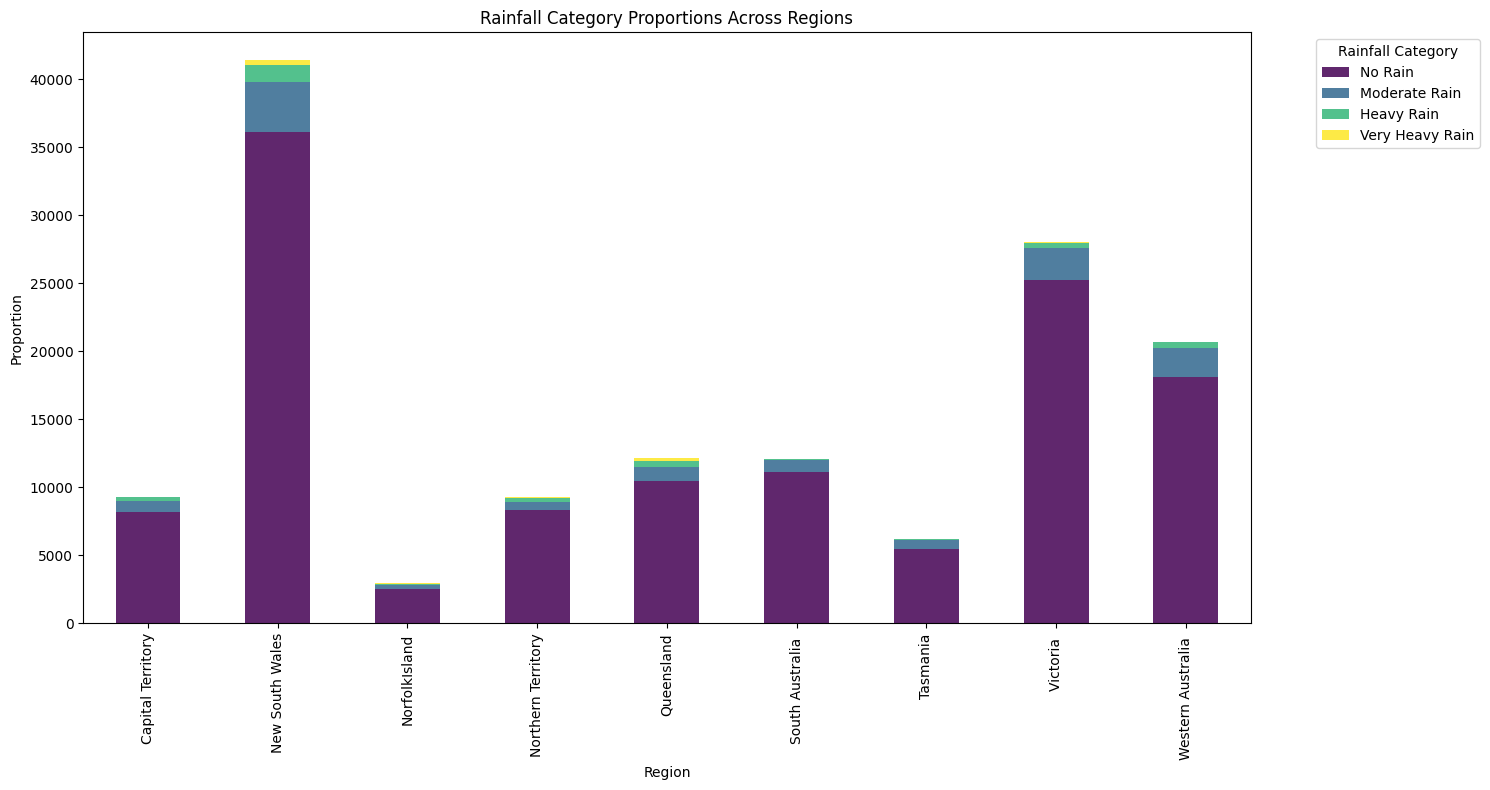

In [ ]:
rainfall_by_region = df1.groupby(['Region', 'Rainfall_Category']).size().unstack(fill_value=0)
rainfall_by_region.plot(kind='bar', stacked=True, figsize=(15, 8), colormap='viridis', alpha=0.85)
plt.title('Rainfall Category Proportions Across Regions')
plt.xlabel('Region')
plt.ylabel('Proportion')
plt.legend(title='Rainfall Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=90)  # Rotate x-axis labels vertically
plt.tight_layout()
plt.show()


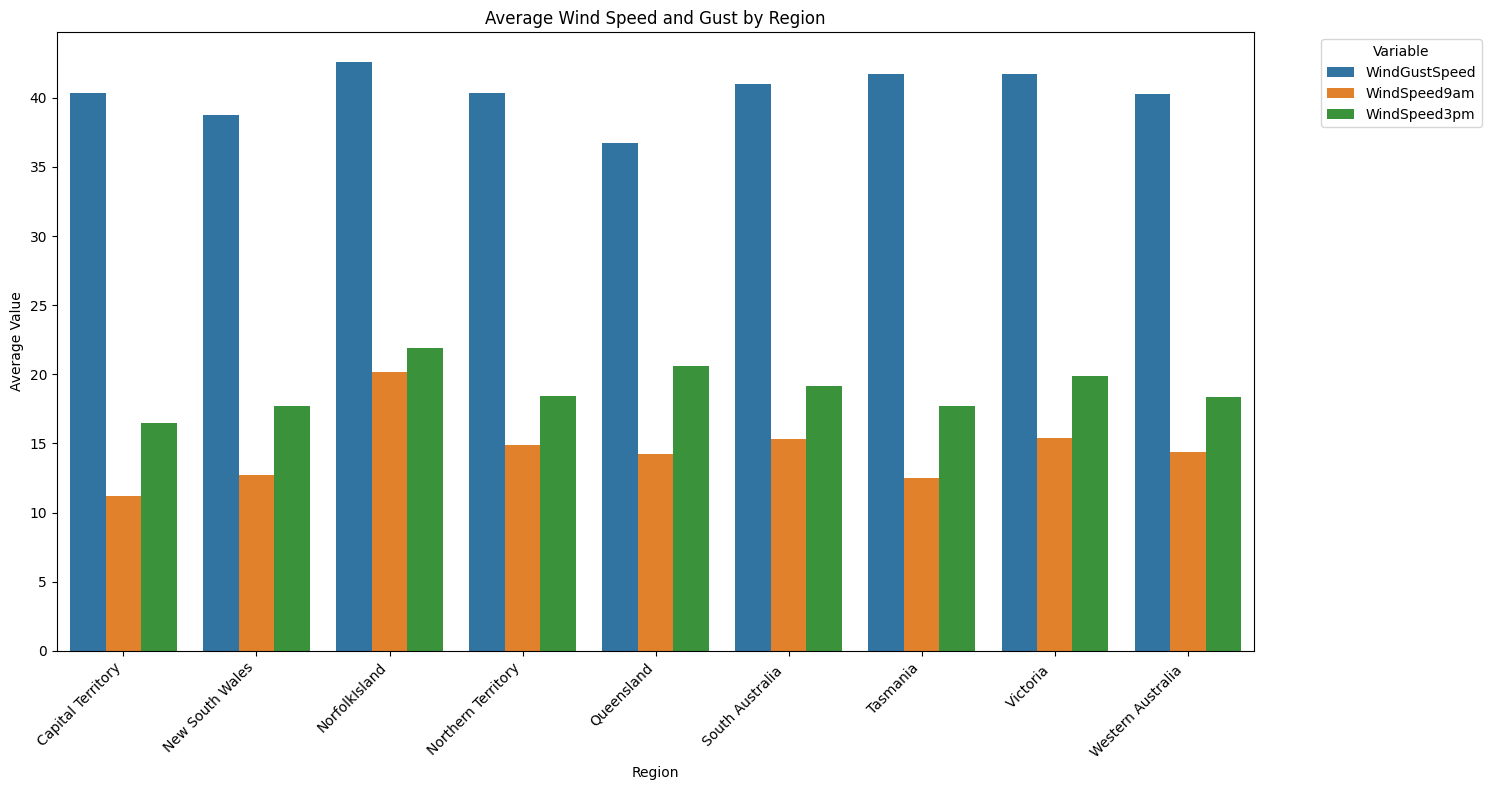

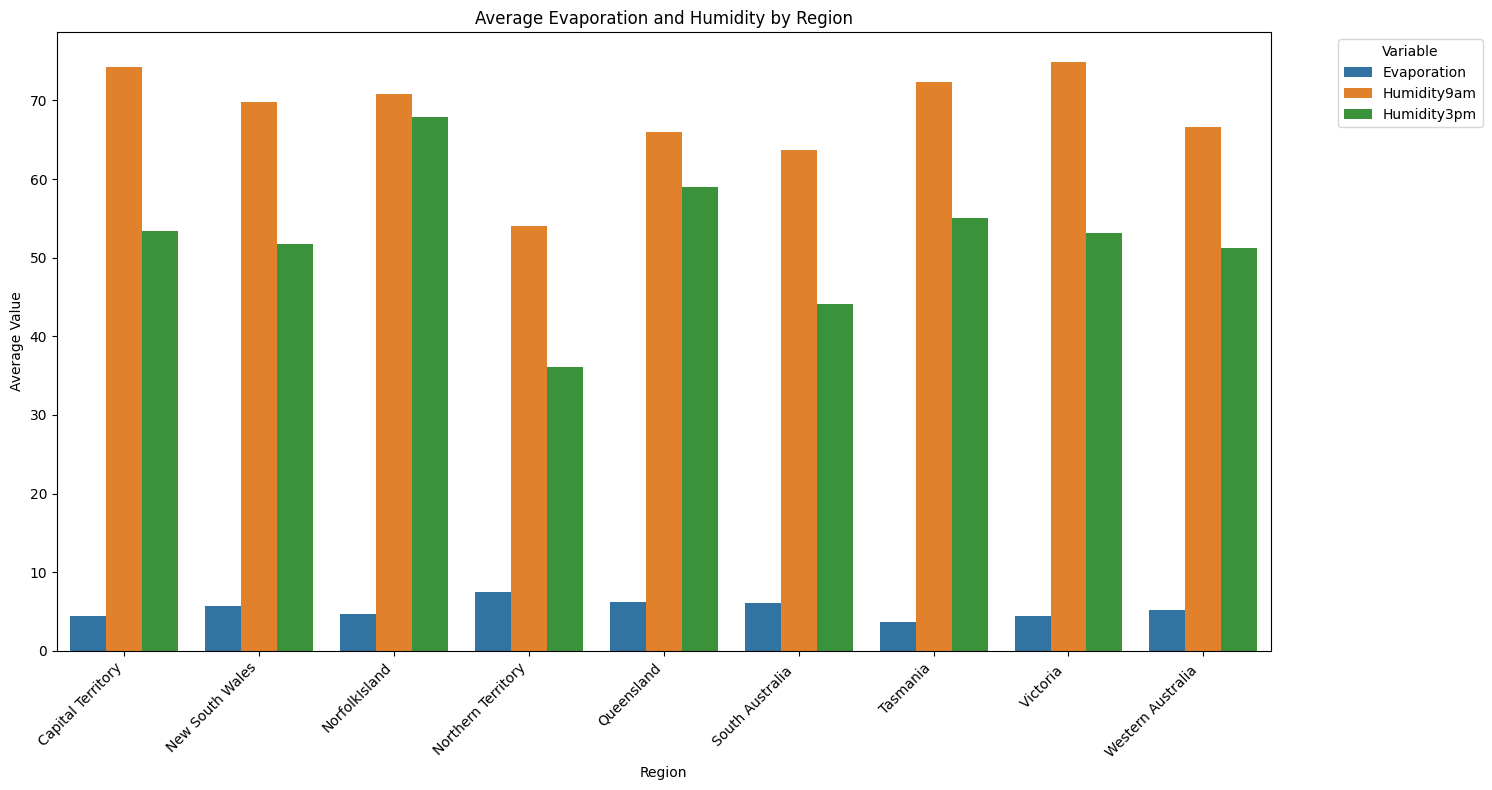

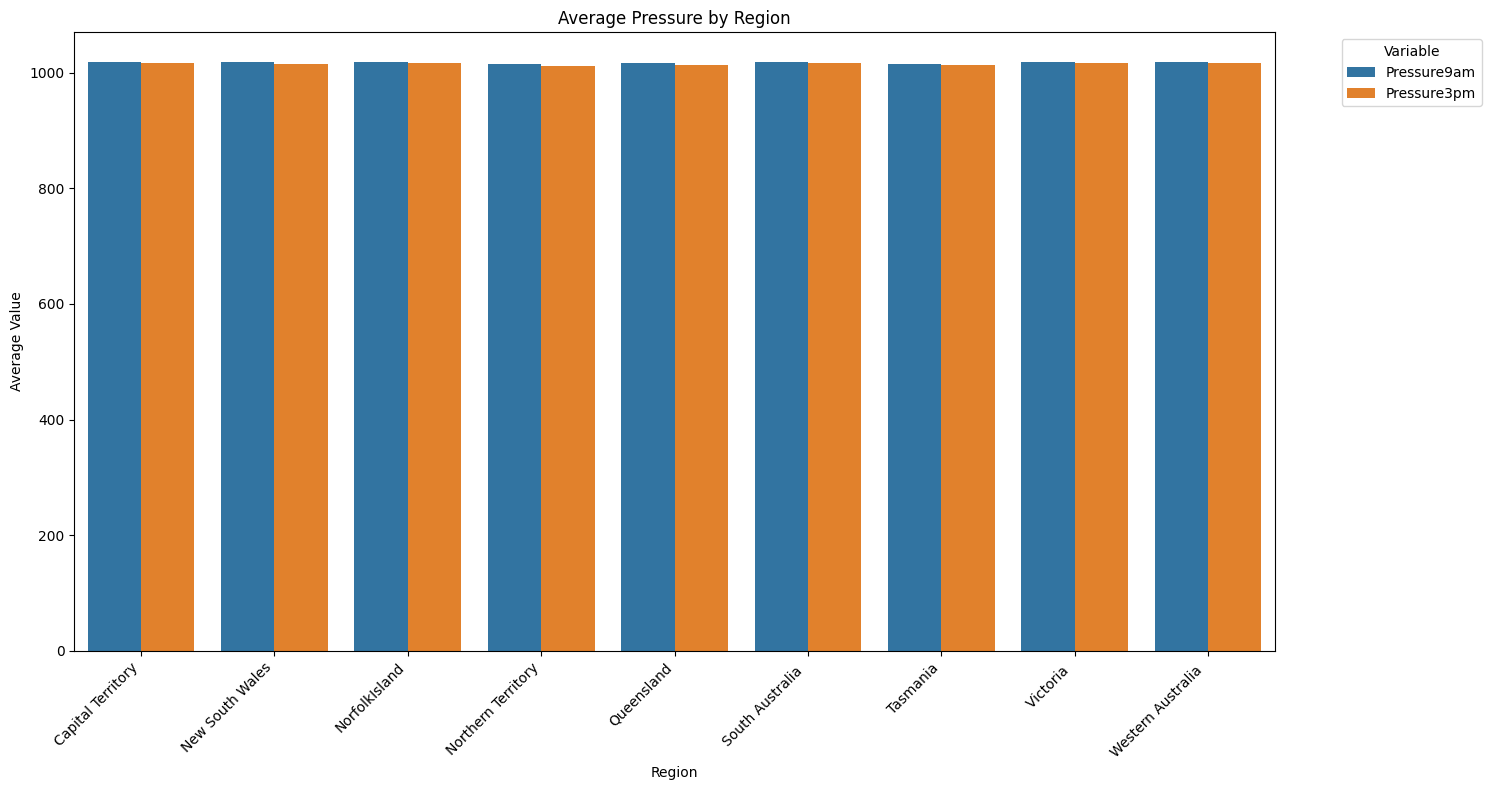

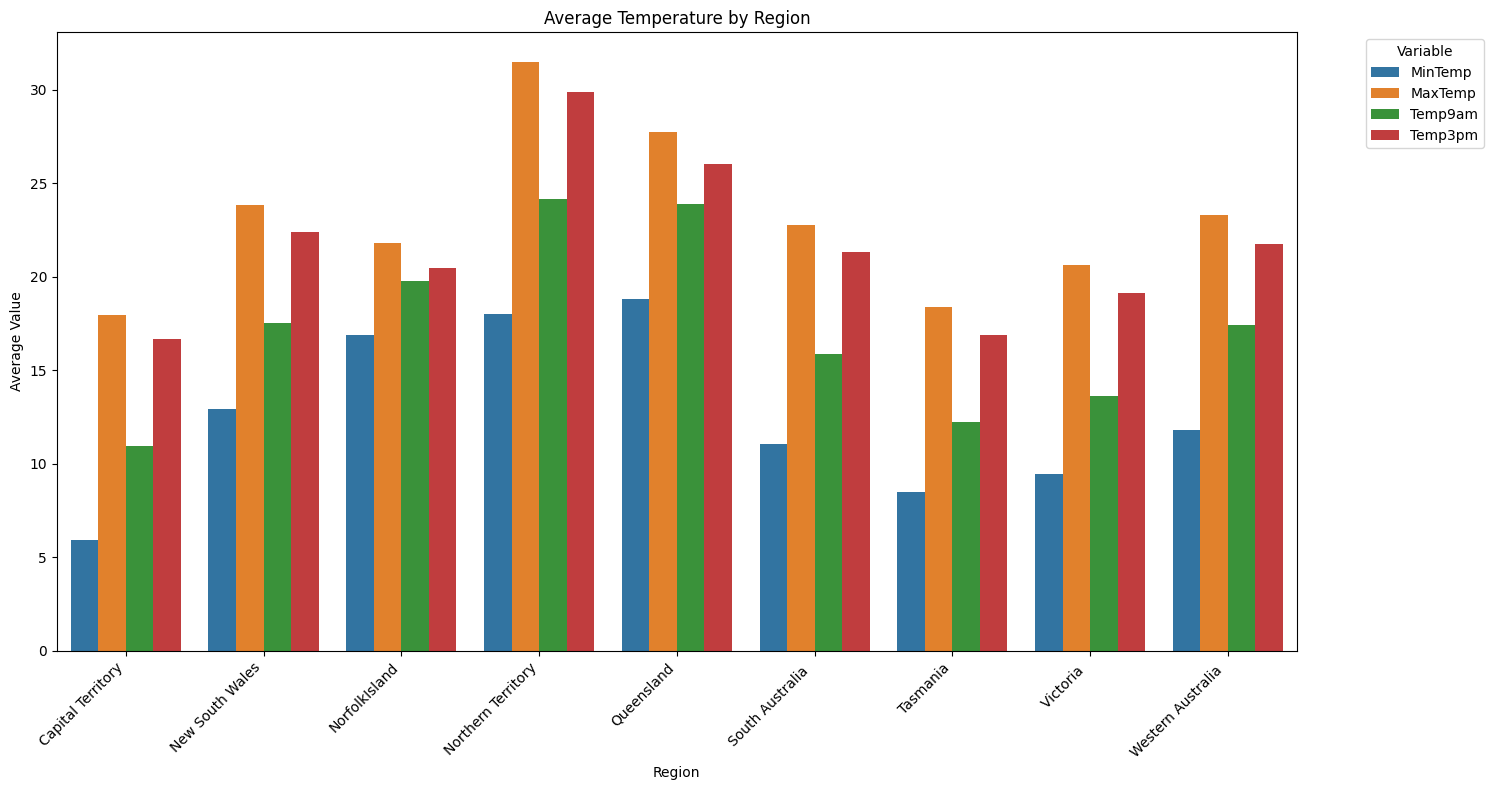

In [ ]:
# Ensure 'Region' column exists in df1
if 'Region' not in df1.columns:
    df1['Region'] = df1['Location'].map(location_to_region)

# Define groups of variables
group1 = ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm']
group2 = ['Evaporation', 'Humidity9am', 'Humidity3pm']
group3 = ['Pressure9am', 'Pressure3pm']
group4 = ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm']

# Function to plot grouped bar plots
def plot_grouped_bar(data, group, title):
    region_data = data.groupby('Region')[group].mean().reset_index()
    melted_data = region_data.melt(id_vars='Region', var_name='Variable', value_name='Value')
    plt.figure(figsize=(15, 8))
    sns.barplot(x='Region', y='Value', hue='Variable', data=melted_data)
    plt.title(title)
    plt.xlabel('Region')
    plt.ylabel('Average Value')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Variable', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Plot each group
plot_grouped_bar(df1, group1, 'Average Wind Speed and Gust by Region')
plot_grouped_bar(df1, group2, 'Average Evaporation and Humidity by Region')
plot_grouped_bar(df1, group3, 'Average Pressure by Region')
plot_grouped_bar(df1, group4, 'Average Temperature by Region')


In [ ]:
# Drop 'RainToday' and 'RainTomorrow' columns
df1.drop(['RainToday', 'RainTomorrow'], axis=1, inplace=True)

In [ ]:

df_encoded = df1.copy()  # Create a copy of the original DataFrame

# One-Hot Encode the 'Rainfall_Category' column without dropping any category
one_hot_encoder = OneHotEncoder(sparse_output=False)  # Use `sparse_output=False` instead of `sparse=False`
encoded_columns = one_hot_encoder.fit_transform(df_encoded[['Rainfall_Category']])
encoded_df = pd.DataFrame(encoded_columns, columns=one_hot_encoder.get_feature_names_out(['Rainfall_Category']))
df_encoded = pd.concat([df_encoded.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

#ENCODING
directions = {'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5, 'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
              'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5, 'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5}
# Manual Target Encoding for Location
location_means = df_encoded.groupby('Location')['Rainfall'].mean()
df_encoded['Location_Target_Encoded'] = df_encoded['Location'].map(location_means)
df_encoded.drop('Location', axis=1, inplace=True)
# Target Encoding for Region
region_means = df_encoded.groupby('Region')['Rainfall'].mean()
df_encoded['Region_Target_Encoded'] = df_encoded['Region'].map(region_means)
df_encoded.drop('Region', axis=1, inplace=True)  # Drop original Region column if not needed

# Cyclic Encoding for Wind Direction features
for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm']:
    df_encoded[f'{col}_sin'] = df_encoded[col].map(directions).apply(lambda x: np.sin(np.radians(x)) if not pd.isna(x) else np.nan)
    df_encoded[f'{col}_cos'] = df_encoded[col].map(directions).apply(lambda x: np.cos(np.radians(x)) if not pd.isna(x) else np.nan)
    df_encoded.drop(col, axis=1, inplace=True)

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 33 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               145460 non-null  datetime64[ns]
 1   MinTemp                            143975 non-null  float64       
 2   MaxTemp                            144199 non-null  float64       
 3   Rainfall                           142199 non-null  float64       
 4   Evaporation                        82670 non-null   float64       
 5   Sunshine                           75625 non-null   float64       
 6   WindGustSpeed                      135197 non-null  float64       
 7   WindSpeed9am                       143693 non-null  float64       
 8   WindSpeed3pm                       142398 non-null  float64       
 9   Humidity9am                        142806 non-null  float64       
 10  Humidity3pm         

In [ ]:
df_encoded.drop(['Rainfall_Category_nan'], axis=1, inplace=True)

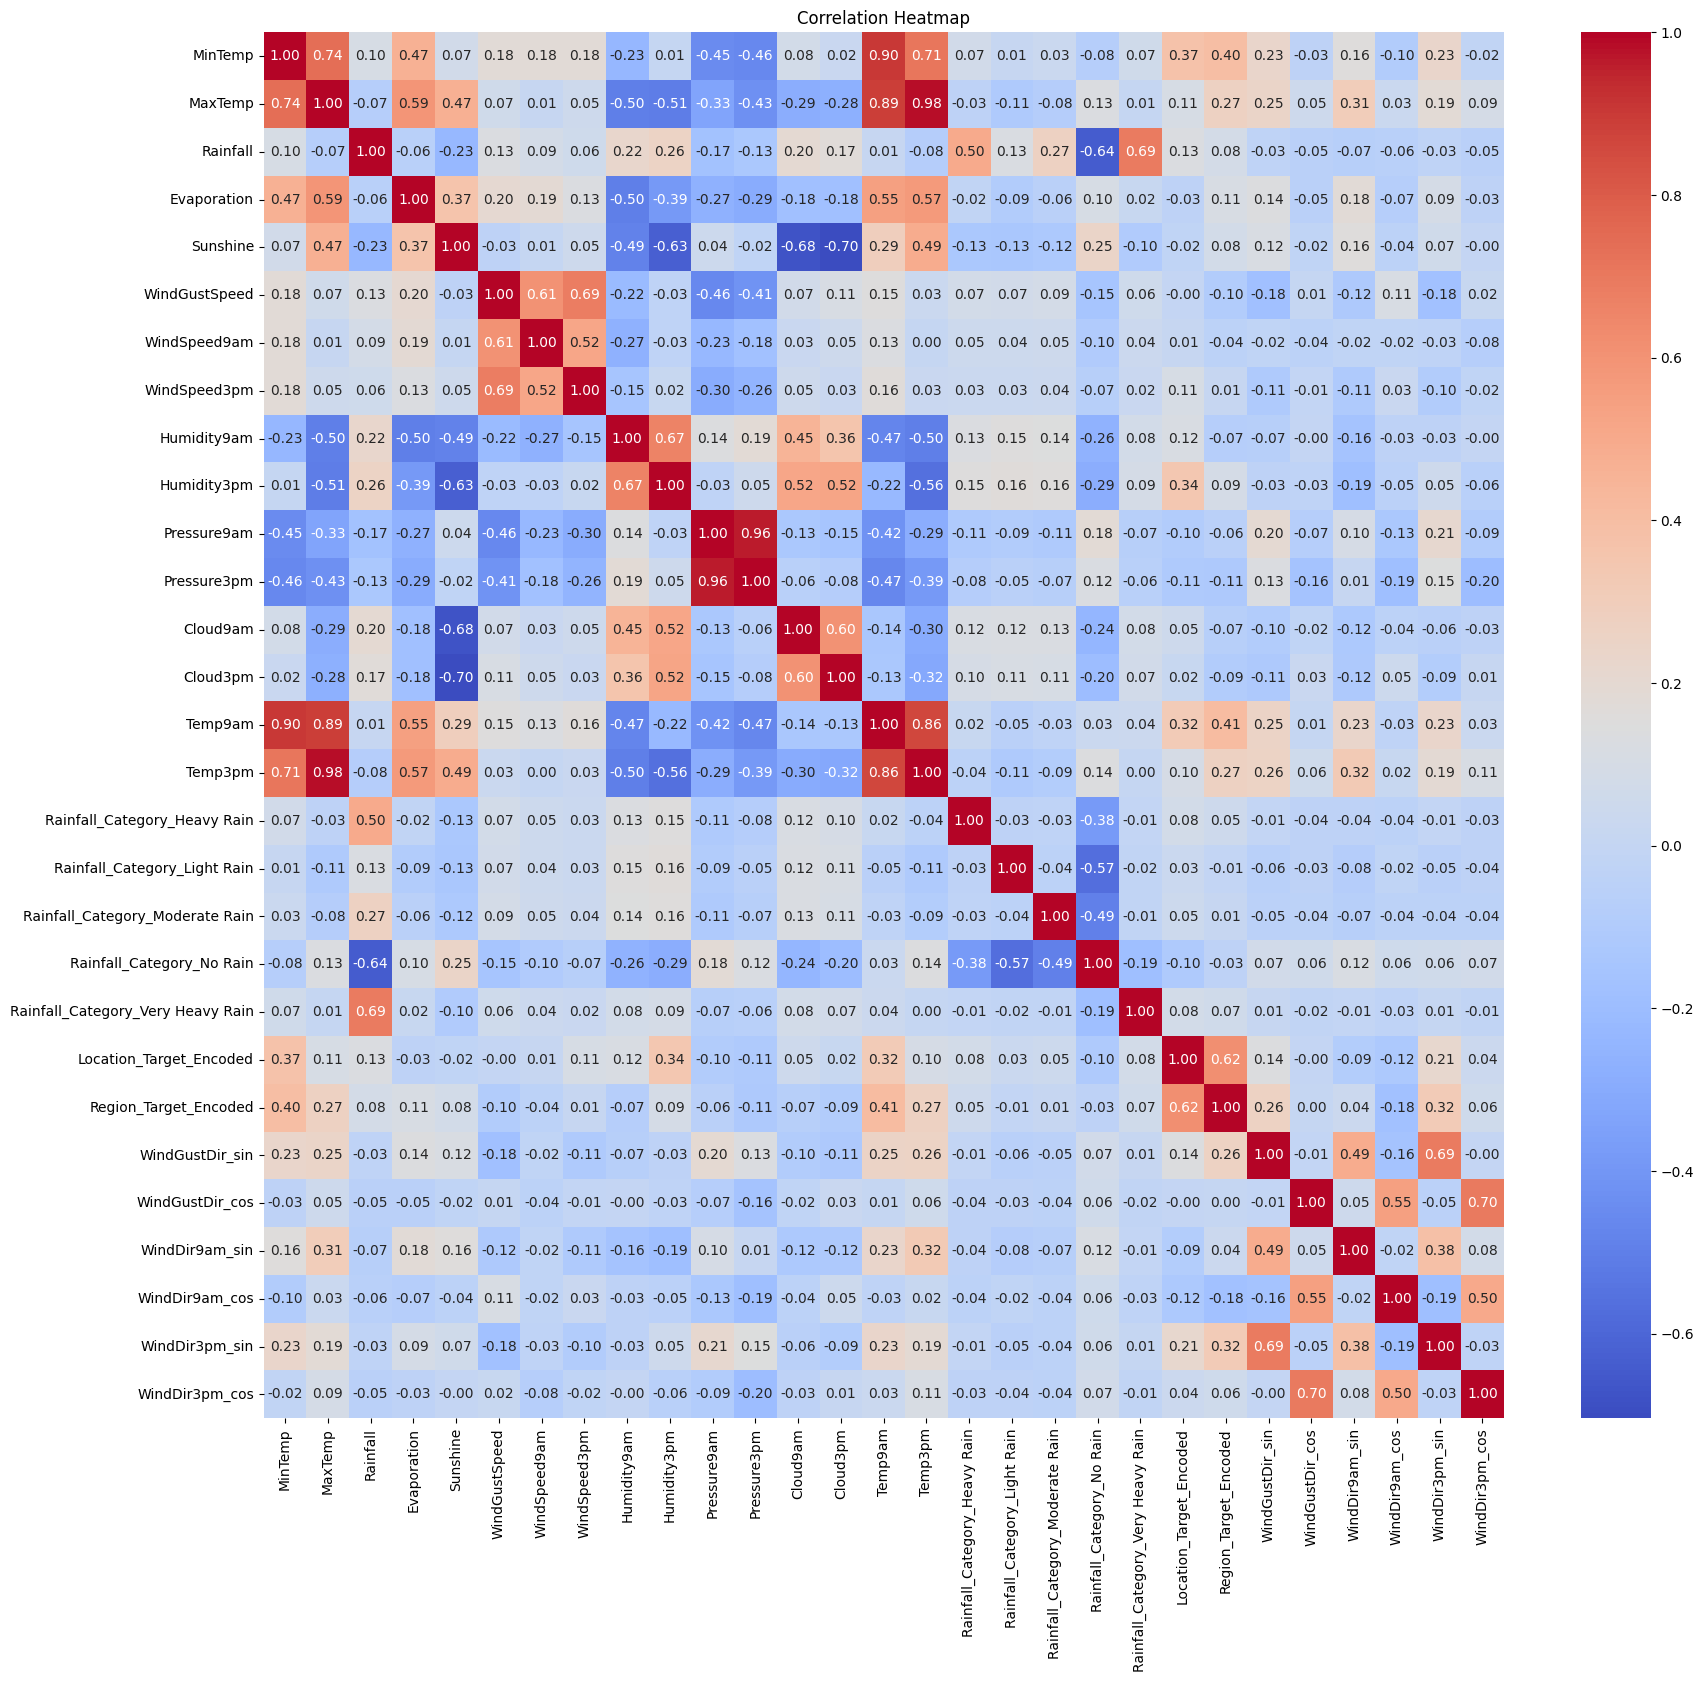

In [ ]:
# Drop non-numeric columns
df_numeric = df_encoded.select_dtypes(include=[np.number])

# Calculate the correlation matrix
correlation_matrix = df_numeric.corr()

# Plot the heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


# Correlation


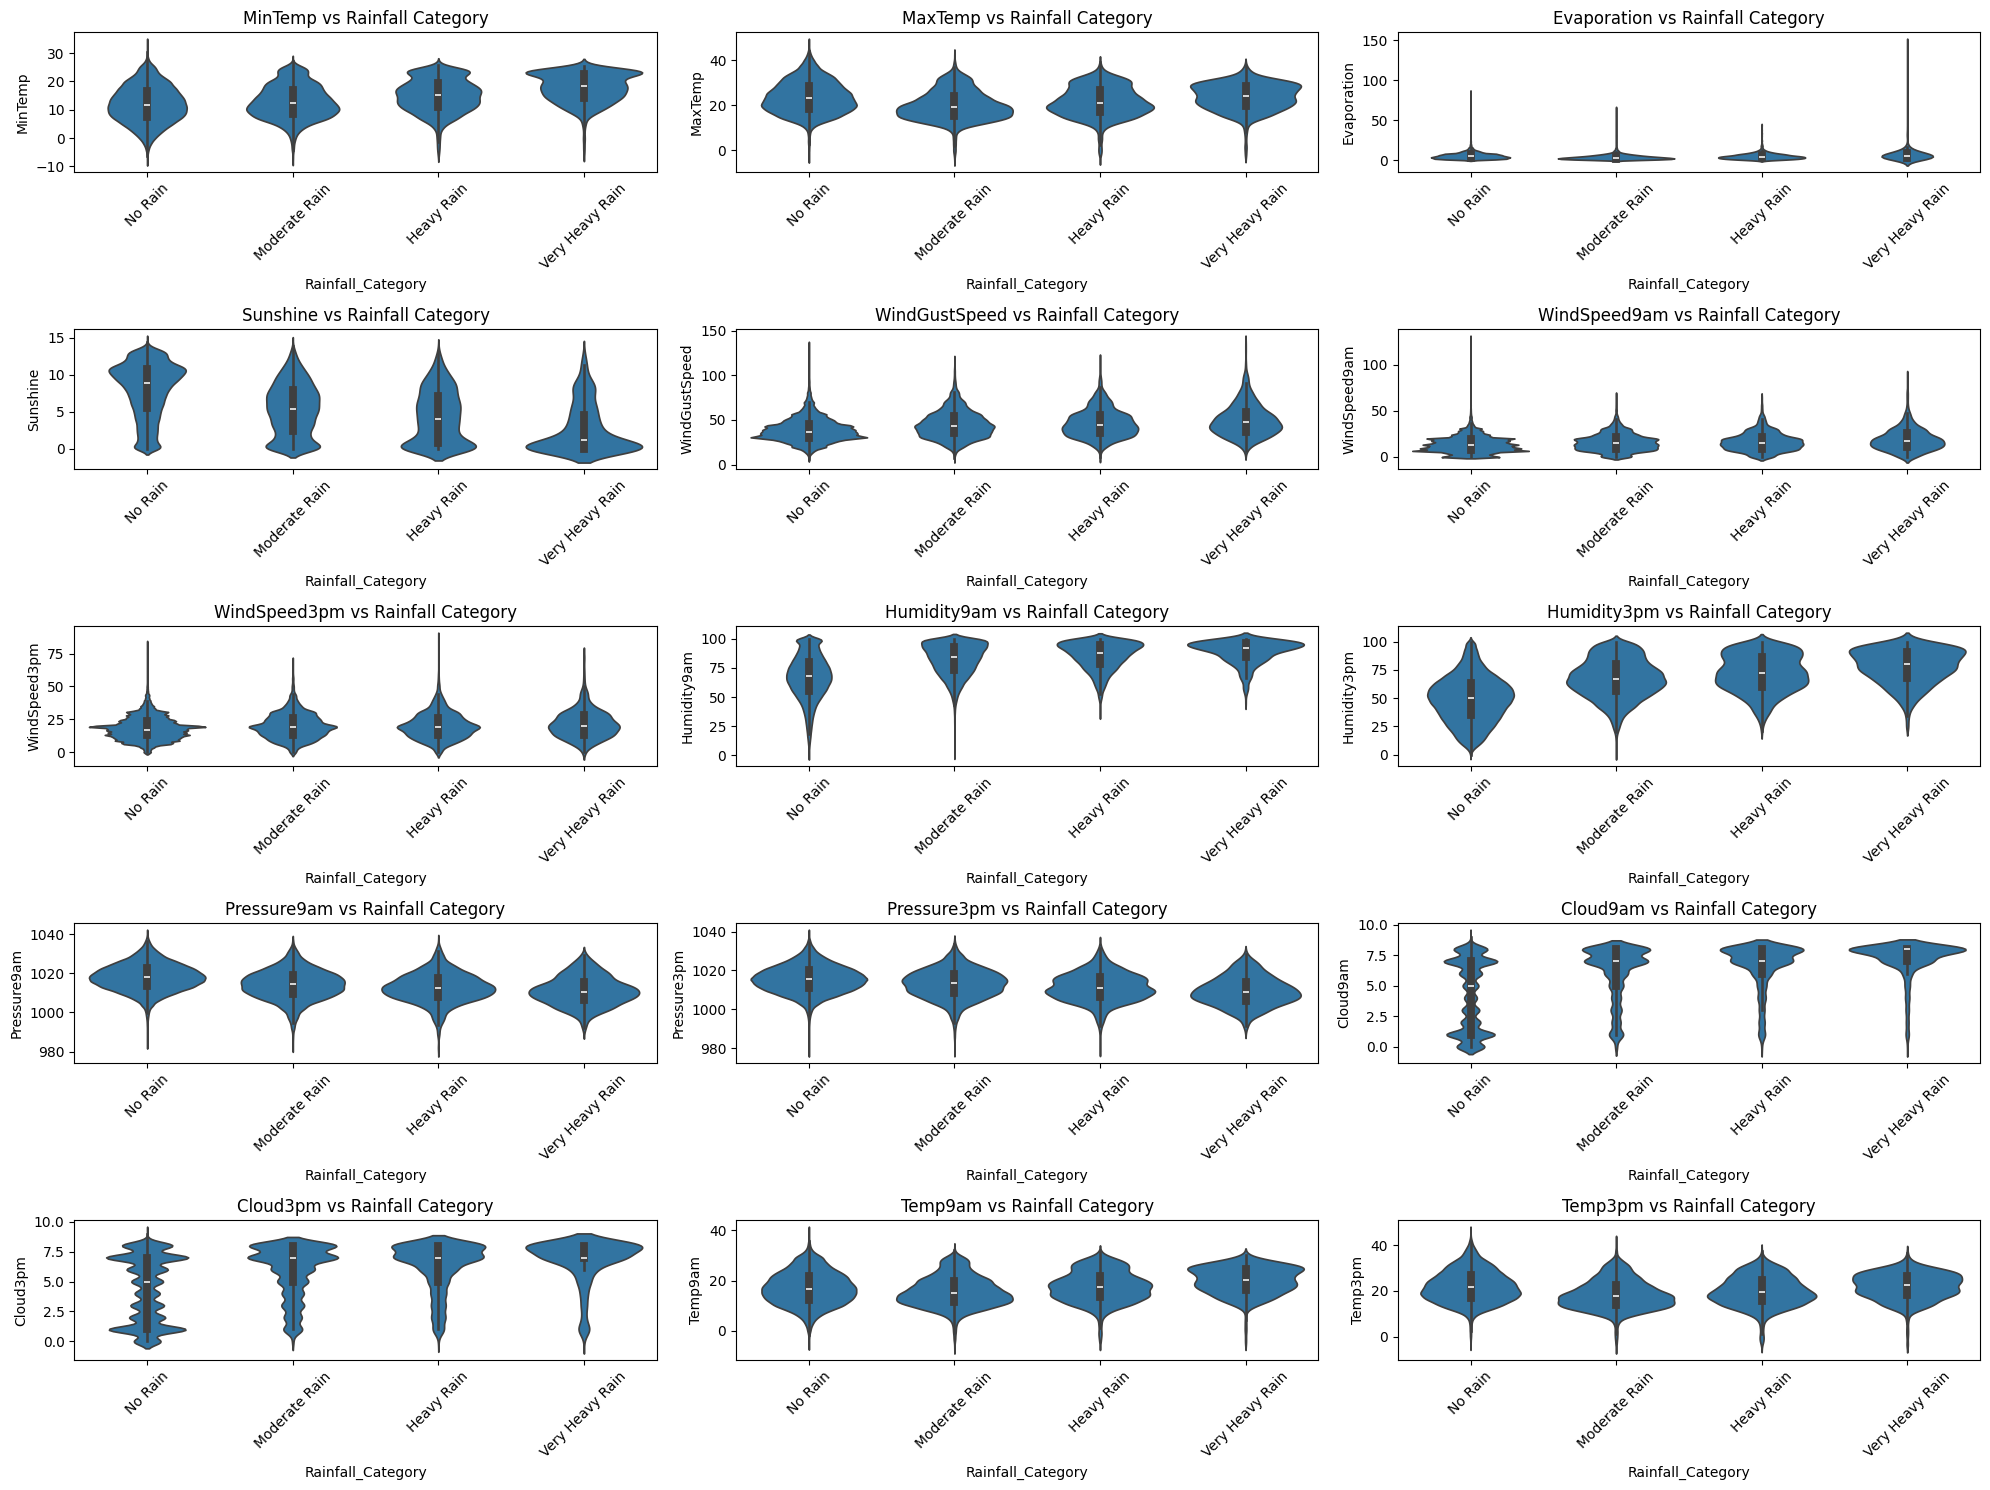

In [ ]:
# Define the list of variables to plot
variables = ['MinTemp', 'MaxTemp', 'Evaporation', 'Sunshine',
             'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
             'Humidity9am', 'Humidity3pm', 'Pressure9am',
             'Pressure3pm', 'Cloud9am', 'Cloud3pm',
             'Temp9am', 'Temp3pm']

# Create violin plots for each variable
plt.figure(figsize=(20, 15))
for i, var in enumerate(variables, 1):
    plt.subplot(5, 3, i)  # Adjust rows and columns based on the number of variables
    sns.violinplot(x='Rainfall_Category', y=var, data=df1)
    plt.title(f'{var} vs Rainfall Category')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Found missing values in Rainfall_Category. Dropping corresponding rows.


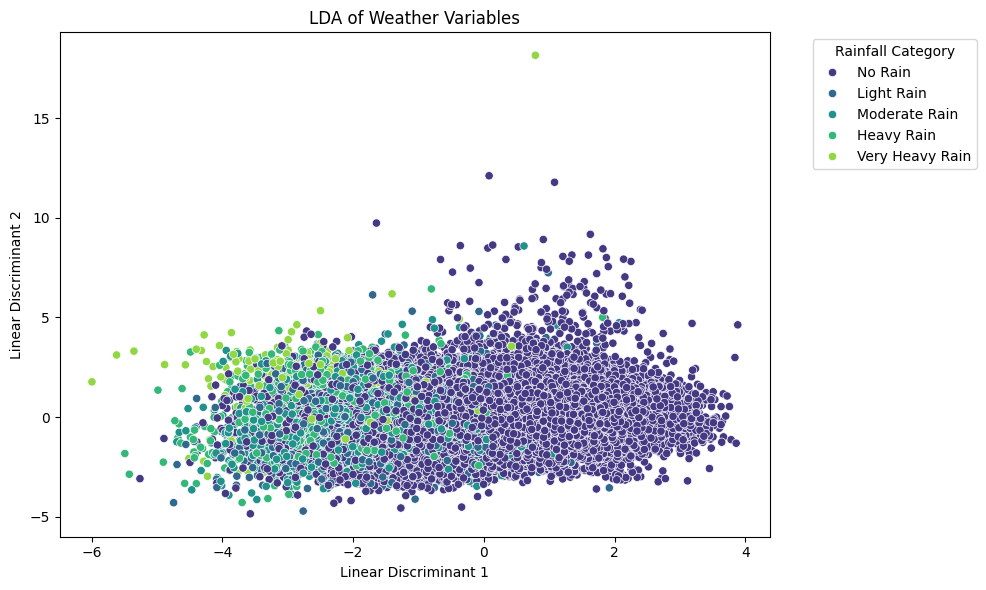

In [ ]:

# Select numerical columns
numerical_data = df_encoded[['MinTemp', 'MaxTemp', 'Evaporation', 'Sunshine',
                             'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
                             'Humidity9am', 'Humidity3pm', 'Pressure9am',
                             'Pressure3pm', 'Cloud9am', 'Cloud3pm',
                             'Temp9am', 'Temp3pm']]

# Handle missing values in numerical data
numerical_data = numerical_data.fillna(numerical_data.mean())  # Fill missing values with column mean

# Ensure Rainfall_Category has no missing values
if df_encoded['Rainfall_Category'].isnull().sum() > 0:
    print("Found missing values in Rainfall_Category. Dropping corresponding rows.")
    df_encoded = df_encoded.dropna(subset=['Rainfall_Category'])
    numerical_data = numerical_data.loc[df_encoded.index]  # Match indices

# Perform LDA
lda = LinearDiscriminantAnalysis(n_components=2)
lda_components = lda.fit_transform(numerical_data, df_encoded['Rainfall_Category'])

# Create a DataFrame for the LDA results
lda_df = pd.DataFrame(lda_components, columns=['LD1', 'LD2'])
lda_df['Rainfall_Category'] = df_encoded['Rainfall_Category'].values

# Scatter plot of LDA components
plt.figure(figsize=(10, 6))
sns.scatterplot(x='LD1', y='LD2', hue='Rainfall_Category', data=lda_df, palette='viridis')
plt.title('LDA of Weather Variables')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.legend(title='Rainfall Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Visualize relationships between numerical variables and identify potential trends, clusters, or outliers.
Non-linear relationships
Clusters or separations between categories
Outliers

In [ ]:
df = pd.read_csv('/content/weatherAUS.csv')

In [ ]:
# Define updated bins and labels
bins = [0, 5, 20, 50, float('inf')] # the last bin to include all rainfall > 50mm
labels = ['No Rain', 'Moderate Rain', 'Heavy Rain', 'Very Heavy Rain']

# Add a new column to df with binned categories
df['Rainfall_Category'] = pd.cut(df['Rainfall'], bins=bins, labels=labels, right=False)

# Check the distribution of each category
rainfall_category_counts = df['Rainfall_Category'].value_counts()
print("Rainfall Category Distribution:\n", rainfall_category_counts)

# Calculate proportions of each category
rainfall_category_proportions = df['Rainfall_Category'].value_counts(normalize=True) * 100
print("Rainfall Category Proportions (%):\n", rainfall_category_proportions)

Rainfall Category Distribution:
 Rainfall_Category
No Rain            125638
Moderate Rain       12478
Heavy Rain           3275
Very Heavy Rain       808
Name: count, dtype: int64
Rainfall Category Proportions (%):
 Rainfall_Category
No Rain            88.353645
Moderate Rain       8.775027
Heavy Rain          2.303110
Very Heavy Rain     0.568218
Name: proportion, dtype: float64


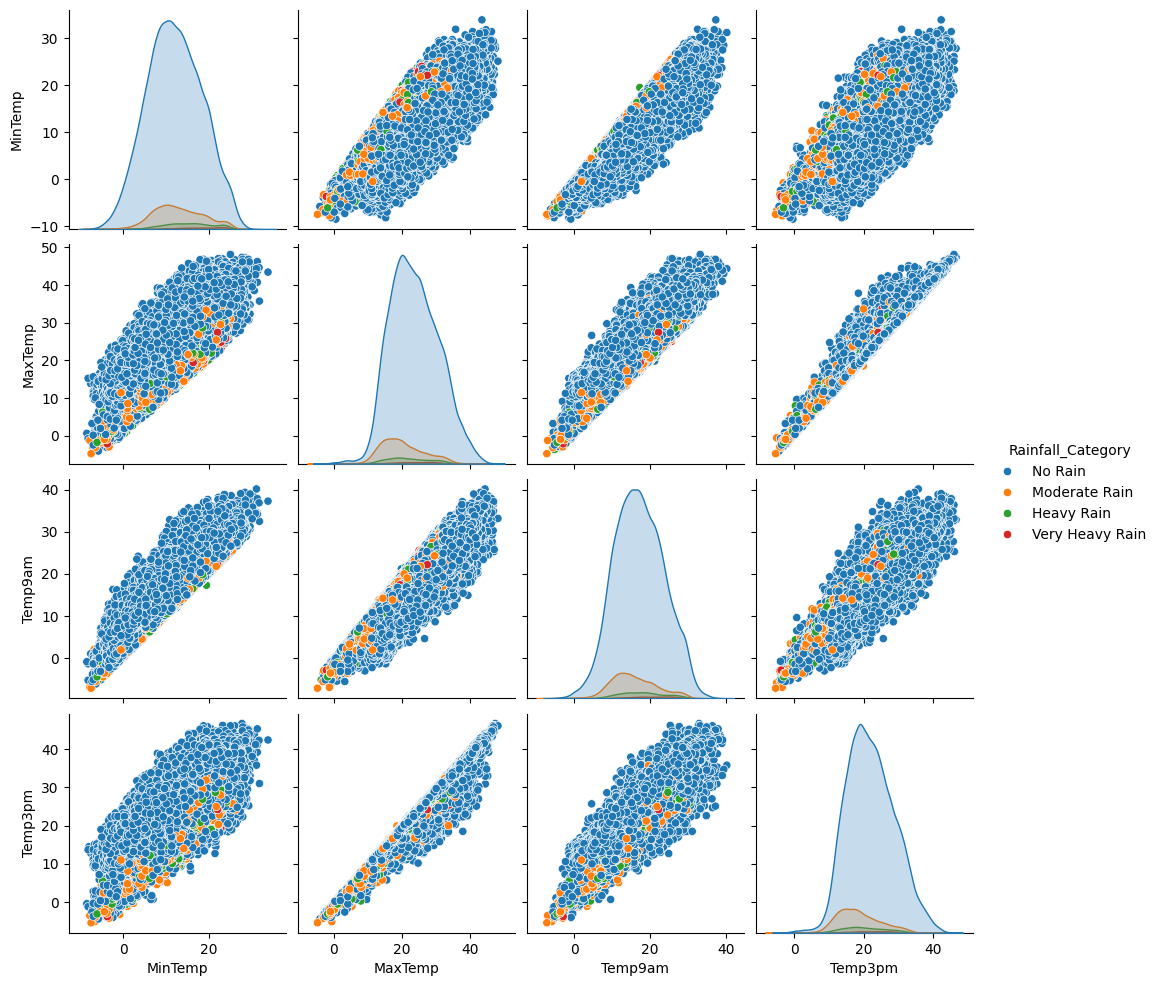

In [ ]:

sns.pairplot(df, hue='Rainfall_Category', vars=['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm'])
plt.show()

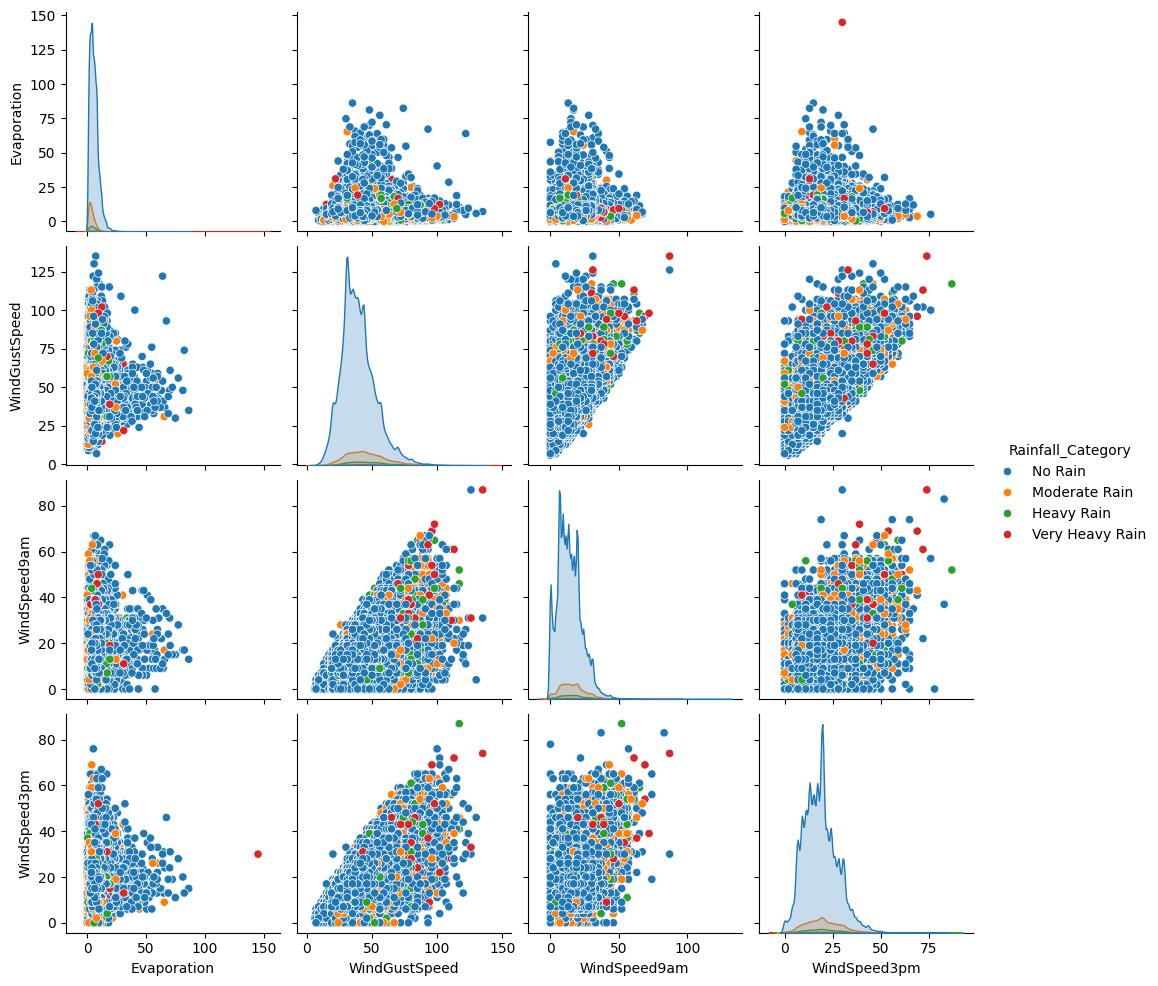

In [ ]:
sns.pairplot(df, hue='Rainfall_Category', vars=['Evaporation', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm'])
plt.show()

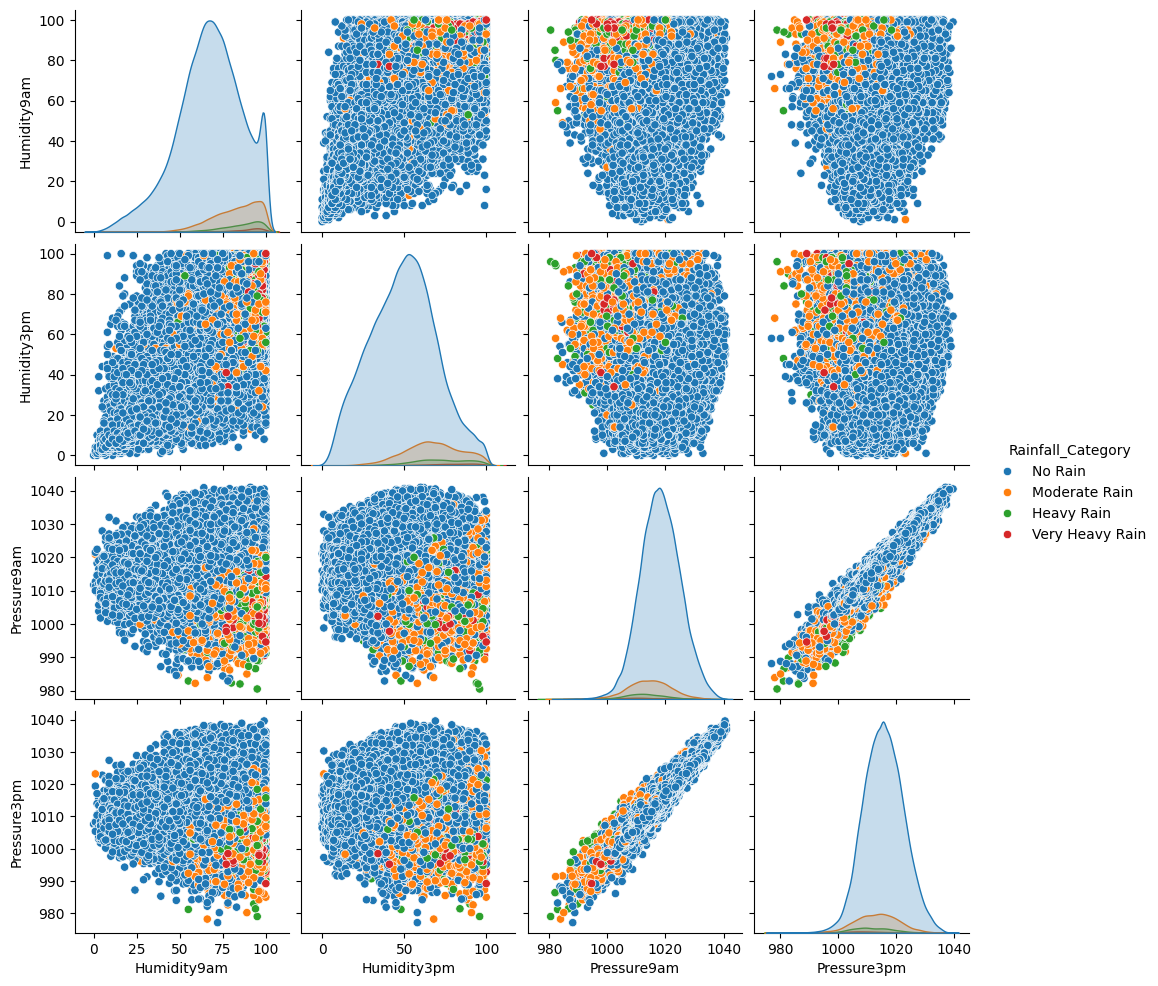

In [ ]:
sns.pairplot(df, hue='Rainfall_Category', vars=['Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm'])
plt.show()